# Bunch of frequency stuff tried out

In [ ]:
# ============================================================================
# Field-frequency extractor (local oscillation frequency of phi_central)
#
# Estimates the local angular/ordinary frequency from the spacing of consecutive
# extrema of phi_central, both as a function of cosmic time t and as a function
# of expansion N = ln(a).  Because the scalar potential here is asymmetric, the
# GW source frequency is taken to be the field frequency by default
# (omega_source = omega_phi).  The 2*omega_phi identification is NOT applied.
#
# Pure-numpy implementation: no pandas dependency.
# ============================================================================
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import find_peaks


# ---- text-table printers (replace pandas.display) --------------------------
def _print_table(table, title=None, max_rows=40, fmt="{: .6e}"):
    """
    Pretty-print a dict-of-1D-arrays (or 1D-lists) as a fixed-width table.
    """
    if title:
        print(title)
    cols = list(table.keys())
    if not cols:
        print("  (empty table)")
        return
    n = max(len(table[c]) for c in cols)

    def _fmt(v):
        if isinstance(v, (str, np.str_)):
            return str(v)
        try:
            if v is None or (isinstance(v, float) and not np.isfinite(v)):
                return "nan"
            return fmt.format(float(v))
        except (TypeError, ValueError):
            return str(v)

    body = []
    for i in range(n):
        row = []
        for c in cols:
            arr = table[c]
            row.append(_fmt(arr[i]) if i < len(arr) else "")
        body.append(row)

    widths = [max(len(c), *(len(r[j]) for r in body)) if body else len(c)
              for j, c in enumerate(cols)]
    sep = "  "
    header = sep.join(c.rjust(widths[j]) for j, c in enumerate(cols))
    rule = "-" * len(header)
    print(header)
    print(rule)
    if n <= max_rows:
        for r in body:
            print(sep.join(r[j].rjust(widths[j]) for j in range(len(cols))))
    else:
        head = max_rows // 2
        tail = max_rows - head
        for r in body[:head]:
            print(sep.join(r[j].rjust(widths[j]) for j in range(len(cols))))
        print(f"... ({n - head - tail} rows hidden) ...".center(len(header)))
        for r in body[-tail:]:
            print(sep.join(r[j].rjust(widths[j]) for j in range(len(cols))))


def _table_to_csv(table, path):
    """Minimal CSV writer for a dict-of-1D-arrays."""
    cols = list(table.keys())
    n = max(len(table[c]) for c in cols) if cols else 0
    with open(path, "w") as f:
        f.write(",".join(cols) + "\n")
        for i in range(n):
            row = []
            for c in cols:
                arr = table[c]
                v = arr[i] if i < len(arr) else ""
                if isinstance(v, (str, np.str_)):
                    s = str(v)
                else:
                    try:
                        s = "" if v is None else repr(float(v))
                    except (TypeError, ValueError):
                        s = str(v)
                row.append(s)
            f.write(",".join(row) + "\n")


def extract_field_frequency(
    cosmic_time,
    lna,
    phi_central,
    window=(2.0, 3.5),
    prominence=None,
    distance=None,
    smooth=False,
    smoothing_window=None,
    use_minima=False,
    source_mode="field",
    save=False,
    output_dir="analysis_outputs/frequencies",
    label=None,
    show=True,
):
    """
    Extract the local oscillation frequency of phi_central from the spacing of
    its consecutive extrema, in both cosmic time t and expansion N = ln(a).

    Parameters
    ----------
    cosmic_time, lna, phi_central : array_like
        Same-length 1D arrays.  `lna = ln(a)` is the expansion variable.
    window : (float, float) or None
        Analysis window applied in `lna` (NOT in cosmic time).  Default (2.0, 3.5)
        compares all oscillons over the same amount of cosmic expansion.
        `window=None` uses the full available range.
    prominence, distance : passed to `scipy.signal.find_peaks`.
    smooth : bool
        If True, apply a centred moving-average smoothing before peak detection.
    smoothing_window : int or None
        Width (in samples) of the smoothing kernel.  Auto-chosen if None.
    use_minima : bool
        Detect minima instead of maxima (find_peaks on -phi_central).
    source_mode : {"field", "phi_squared", "twice_field"}
        How to define the GW source frequency.
            "field"        -> omega_source = omega_phi               (DEFAULT)
            "phi_squared"  -> omega_source from peak spacing of phi^2
            "twice_field"  -> omega_source = 2 * omega_phi           (diagnostic only)
    save : bool
        If True, save figures and tables to `output_dir`.  Default False.
    output_dir : str or path-like
        Output directory used only when `save=True`.
    label : str or None
        Optional label used in figure titles (e.g. run name).
    show : bool
        If True (default) call plt.show() so the figures render in the notebook.

    Returns
    -------
    dict with keys:
        field_frequency_table     : dict of 1D numpy arrays, one entry per consecutive pair.
        field_frequency_summary   : dict of 1D arrays/lists, summary statistics.
        peak_indices              : ndarray of indices of detected extrema in the
                                    windowed arrays (after sort/dedup/window).
        figures                   : dict[str -> matplotlib.figure.Figure].
        window                    : (lna_min, lna_max) actually used.
        cosmic_time_window        : (t_min, t_max) corresponding to that window.
    """
    if source_mode not in ("field", "phi_squared", "twice_field"):
        raise ValueError(
            f"source_mode must be 'field', 'phi_squared' or 'twice_field' (got {source_mode!r})"
        )

    # ---- 1) sanitize, sort by lna, drop duplicates ---------------------------
    t = np.asarray(cosmic_time, dtype=float).ravel()
    N = np.asarray(lna,         dtype=float).ravel()
    p = np.asarray(phi_central, dtype=float).ravel()

    if not (t.size == N.size == p.size):
        raise ValueError(
            f"cosmic_time, lna, phi_central must have the same length "
            f"(got {t.size}, {N.size}, {p.size})."
        )

    finite = np.isfinite(t) & np.isfinite(N) & np.isfinite(p)
    t, N, p = t[finite], N[finite], p[finite]

    order = np.argsort(N, kind="mergesort")
    t, N, p = t[order], N[order], p[order]

    # remove repeated coordinates (same lna)
    keep = np.concatenate(([True], np.diff(N) > 0))
    t, N, p = t[keep], N[keep], p[keep]

    # ---- 2) apply analysis window in ln(a) -----------------------------------
    if window is None:
        lo, hi = (float(N.min()), float(N.max())) if N.size else (0.0, 0.0)
    else:
        lo, hi = float(window[0]), float(window[1])

    mask = (N >= lo) & (N <= hi)
    t_w, N_w, p_w = t[mask], N[mask], p[mask]

    print("=" * 60)
    print("extract_field_frequency")
    if label is not None:
        print(f"  label                : {label}")
    print(f"  source_mode          : {source_mode}")
    print(f"  use_minima           : {use_minima}")
    print(f"  active window in N   : lna \u2208 [{lo}, {hi}]")
    if t_w.size >= 1:
        print(f"  cosmic-time interval : t \u2208 [{t_w.min():.6g}, {t_w.max():.6g}]")
    else:
        print("  cosmic-time interval : (empty window!)")
    print(f"  samples in window    : {t_w.size}")

    if t_w.size < 8:
        print(f"  WARNING: only {t_w.size} samples inside the window; "
              "results will be unreliable.")

    # ---- 3) optional smoothing ----------------------------------------------
    p_proc = p_w.copy()
    if smooth and p_proc.size > 3:
        if smoothing_window is None:
            sw = max(5, p_proc.size // 100)
        else:
            sw = int(smoothing_window)
        sw = max(3, sw if sw % 2 == 1 else sw + 1)
        if sw < p_proc.size:
            kernel = np.ones(sw) / sw
            p_proc = np.convolve(p_proc, kernel, mode="same")
            print(f"  smoothing            : moving avg, width={sw}")

    # ---- 4) extrema detection -----------------------------------------------
    sig = -p_proc if use_minima else p_proc
    fp_kwargs = {}
    if prominence is not None: fp_kwargs["prominence"] = prominence
    if distance   is not None: fp_kwargs["distance"]   = distance
    peak_indices, _ = find_peaks(sig, **fp_kwargs)

    extrema_word = "minima" if use_minima else "maxima"
    print(f"  extrema detected     : {peak_indices.size} {extrema_word}")
    if peak_indices.size < 3:
        print(f"  WARNING: fewer than 3 extrema were found; "
              "frequency estimate will be very poor.")

    # ---- 5/6/7) periods and midpoints ---------------------------------------
    t_pk = t_w[peak_indices]
    N_pk = N_w[peak_indices]
    p_pk = p_w[peak_indices]

    if peak_indices.size >= 2:
        Delta_t = np.diff(t_pk)
        Delta_N = np.diff(N_pk)
        t_mid   = 0.5 * (t_pk[1:] + t_pk[:-1])
        N_mid   = 0.5 * (N_pk[1:] + N_pk[:-1])
    else:
        Delta_t = np.array([])
        Delta_N = np.array([])
        t_mid   = np.array([])
        N_mid   = np.array([])

    if Delta_t.size and (Delta_t <= 0).any():
        print("  WARNING: non-positive \u0394t detected -- extrema are not strictly "
              "increasing in cosmic time; check input ordering.")
    if Delta_N.size and (Delta_N <= 0).any():
        print("  WARNING: non-positive \u0394N detected -- extrema are not strictly "
              "increasing in ln(a).")

    # ---- 8) field frequencies ------------------------------------------------
    with np.errstate(divide="ignore", invalid="ignore"):
        omega_phi_t = 2.0 * np.pi / Delta_t
        f_phi_t     = 1.0 / Delta_t
        omega_phi_N = 2.0 * np.pi / Delta_N
        f_phi_N     = 1.0 / Delta_N

    # ---- 9) source frequency definition --------------------------------------
    source_extras = None
    if source_mode == "field":
        omega_source_t = omega_phi_t.copy()
        f_source_t     = f_phi_t.copy()
        omega_source_N = omega_phi_N.copy()
        f_source_N     = f_phi_N.copy()
    elif source_mode == "twice_field":
        omega_source_t = 2.0 * omega_phi_t
        f_source_t     = 2.0 * f_phi_t
        omega_source_N = 2.0 * omega_phi_N
        f_source_N     = 2.0 * f_phi_N
    else:  # source_mode == "phi_squared"
        p2 = p_proc ** 2
        sq_idx, _ = find_peaks(p2, **fp_kwargs)
        if sq_idx.size >= 2:
            t_sq, N_sq = t_w[sq_idx], N_w[sq_idx]
            Dt_sq, DN_sq = np.diff(t_sq), np.diff(N_sq)
            tmid_sq = 0.5 * (t_sq[1:] + t_sq[:-1])
            Nmid_sq = 0.5 * (N_sq[1:] + N_sq[:-1])
            with np.errstate(divide="ignore", invalid="ignore"):
                om_sq_t = 2.0 * np.pi / Dt_sq
                f_sq_t  = 1.0 / Dt_sq
                om_sq_N = 2.0 * np.pi / DN_sq
                f_sq_N  = 1.0 / DN_sq
            # interpolate onto the field-peak midpoints so the table is aligned
            if t_mid.size and tmid_sq.size >= 2:
                omega_source_t = np.interp(t_mid, tmid_sq, om_sq_t)
                f_source_t     = np.interp(t_mid, tmid_sq, f_sq_t)
                omega_source_N = np.interp(N_mid, Nmid_sq, om_sq_N)
                f_source_N     = np.interp(N_mid, Nmid_sq, f_sq_N)
            else:
                omega_source_t = np.full_like(omega_phi_t, np.nan)
                f_source_t     = np.full_like(f_phi_t,     np.nan)
                omega_source_N = np.full_like(omega_phi_N, np.nan)
                f_source_N     = np.full_like(f_phi_N,     np.nan)
            source_extras = dict(
                phi2=p2, peak_indices=sq_idx,
                t_peak=t_sq, N_peak=N_sq,
                t_mid=tmid_sq, N_mid=Nmid_sq,
                omega_t=om_sq_t, f_t=f_sq_t,
                omega_N=om_sq_N, f_N=f_sq_N,
            )
            print(f"  phi^2 peaks detected : {sq_idx.size}")
        else:
            omega_source_t = np.full_like(omega_phi_t, np.nan)
            f_source_t     = np.full_like(f_phi_t,     np.nan)
            omega_source_N = np.full_like(omega_phi_N, np.nan)
            f_source_N     = np.full_like(f_phi_N,     np.nan)
            print("  WARNING: <2 phi^2 peaks; omega_source set to NaN.")

    # ---- table (dict of numpy arrays) ---------------------------------------
    field_frequency_table = {
        "t_mid":          np.asarray(t_mid,          dtype=float),
        "N_mid":          np.asarray(N_mid,          dtype=float),
        "Delta_t":        np.asarray(Delta_t,        dtype=float),
        "Delta_N":        np.asarray(Delta_N,        dtype=float),
        "omega_phi_t":    np.asarray(omega_phi_t,    dtype=float),
        "f_phi_t":        np.asarray(f_phi_t,        dtype=float),
        "omega_source_t": np.asarray(omega_source_t, dtype=float),
        "f_source_t":     np.asarray(f_source_t,     dtype=float),
        "omega_phi_N":    np.asarray(omega_phi_N,    dtype=float),
        "f_phi_N":        np.asarray(f_phi_N,        dtype=float),
        "omega_source_N": np.asarray(omega_source_N, dtype=float),
        "f_source_N":     np.asarray(f_source_N,     dtype=float),
    }

    # frequency-stability diagnostic
    def _rel_var(a):
        a = a[np.isfinite(a)]
        if a.size < 2 or np.mean(a) == 0: return np.nan
        return float(np.std(a) / np.abs(np.mean(a)))

    rv_t = _rel_var(omega_phi_t)
    rv_N = _rel_var(omega_phi_N)
    if np.isfinite(rv_t) and rv_t > 0.5:
        print(f"  WARNING: omega_phi_t varies strongly across window "
              f"(std/mean = {rv_t:.3f}).")
    if np.isfinite(rv_N) and rv_N > 0.5:
        print(f"  WARNING: omega_phi_N varies strongly across window "
              f"(std/mean = {rv_N:.3f}).")
    if np.isfinite(rv_t) and rv_t > 1.0:
        print("  WARNING: extrema detection looks unstable (>100% variation).")

    # ---- summary (dict of 1D arrays/lists) -----------------------------------
    quantity_names  = []
    coordinate_list = []
    n_periods       = []
    means           = []
    medians         = []
    stds            = []
    mins            = []
    maxs            = []

    for col, coord in [
        ("omega_phi_t",    "t"),
        ("f_phi_t",        "t"),
        ("omega_source_t", "t"),
        ("f_source_t",     "t"),
        ("omega_phi_N",    "N"),
        ("f_phi_N",        "N"),
        ("omega_source_N", "N"),
        ("f_source_N",     "N"),
    ]:
        s = field_frequency_table[col]
        s = s[np.isfinite(s)]
        quantity_names.append(col)
        coordinate_list.append(coord)
        n_periods.append(int(s.size))
        means  .append(float(np.mean(s))   if s.size else np.nan)
        medians.append(float(np.median(s)) if s.size else np.nan)
        stds   .append(float(np.std(s))    if s.size else np.nan)
        mins   .append(float(np.min(s))    if s.size else np.nan)
        maxs   .append(float(np.max(s))    if s.size else np.nan)

    field_frequency_summary = {
        "quantity":          quantity_names,
        "coordinate":        coordinate_list,
        "number_of_periods": np.asarray(n_periods, dtype=int),
        "mean":              np.asarray(means,     dtype=float),
        "median":            np.asarray(medians,   dtype=float),
        "std":               np.asarray(stds,      dtype=float),
        "min":               np.asarray(mins,      dtype=float),
        "max":               np.asarray(maxs,      dtype=float),
    }

    print()
    _print_table(field_frequency_table,   title="field_frequency_table:")
    print()
    _print_table(field_frequency_summary, title="field_frequency_summary:")

    # ---- plots ---------------------------------------------------------------
    figures = {}
    suffix = f"  [{label}]" if label else ""
    extrema_lbl = r"detected minima" if use_minima else r"detected maxima"

    # 1) phi vs t
    fig1, ax1 = plt.subplots(figsize=(9, 3.5))
    ax1.plot(t_w, p_w, lw=1.0, color="k", label=r"$\phi_{\rm center}(t)$")
    if smooth:
        ax1.plot(t_w, p_proc, lw=1.0, color="tab:blue", alpha=0.7, label="smoothed")
    if peak_indices.size:
        ax1.plot(t_pk, p_pk, "o", ms=4, color="tab:red", label=extrema_lbl)
    ax1.set_xlabel(r"$t$")
    ax1.set_ylabel(r"$\phi_{\rm center}$")
    ax1.set_title(rf"$\phi_{{\rm center}}(t)$ over $N\in[{lo},\,{hi}]${suffix}", fontsize=11)
    ax1.legend(fontsize=9)
    ax1.grid(False)
    fig1.tight_layout()
    figures["phi_vs_t"] = fig1

    # 2) phi vs N
    fig2, ax2 = plt.subplots(figsize=(9, 3.5))
    ax2.plot(N_w, p_w, lw=1.0, color="k", label=r"$\phi_{\rm center}(N)$")
    if smooth:
        ax2.plot(N_w, p_proc, lw=1.0, color="tab:blue", alpha=0.7, label="smoothed")
    if peak_indices.size:
        ax2.plot(N_pk, p_pk, "o", ms=4, color="tab:red", label=extrema_lbl)
    ax2.set_xlabel(r"$N=\ln(a)$")
    ax2.set_ylabel(r"$\phi_{\rm center}$")
    ax2.set_title(rf"$\phi_{{\rm center}}(N)$ over $N\in[{lo},\,{hi}]${suffix}", fontsize=11)
    ax2.legend(fontsize=9)
    ax2.grid(False)
    fig2.tight_layout()
    figures["phi_vs_N"] = fig2

    # 3) omega vs t_mid
    fig3, ax3 = plt.subplots(figsize=(9, 3.5))
    if t_mid.size:
        ax3.plot(t_mid, omega_phi_t,    "o-",  color="tab:blue",   lw=1.0, ms=4,
                 label=r"$\omega_\phi(t)$")
        ax3.plot(t_mid, omega_source_t, "s--", color="tab:orange", lw=1.0, ms=4,
                 label=r"$\omega_{\rm source}(t)$")
    ax3.set_xlabel(r"$t_{\rm mid}$")
    ax3.set_ylabel(r"$\omega$")
    ax3.set_title(rf"Local angular frequency vs $t$  (source mode='{source_mode}'){suffix}",
                  fontsize=11)
    ax3.legend(fontsize=9)
    ax3.grid(False)
    fig3.tight_layout()
    figures["omega_vs_t"] = fig3

    # 4) omega vs N_mid
    fig4, ax4 = plt.subplots(figsize=(9, 3.5))
    if N_mid.size:
        ax4.plot(N_mid, omega_phi_N,    "o-",  color="tab:blue",   lw=1.0, ms=4,
                 label=r"$\omega_\phi(N)$")
        ax4.plot(N_mid, omega_source_N, "s--", color="tab:orange", lw=1.0, ms=4,
                 label=r"$\omega_{\rm source}(N)$")
    ax4.set_xlabel(r"$N_{\rm mid}=\ln(a)_{\rm mid}$")
    ax4.set_ylabel(r"$\omega$")
    ax4.set_title(rf"Local angular frequency vs $N$  (source mode='{source_mode}'){suffix}",
                  fontsize=11)
    ax4.legend(fontsize=9)
    ax4.grid(False)
    fig4.tight_layout()
    figures["omega_vs_N"] = fig4

    # 5) phi^2 diagnostic -- only when source_mode == "phi_squared"
    if source_mode == "phi_squared" and source_extras is not None:
        p2 = source_extras["phi2"]
        sq = source_extras["peak_indices"]
        fig5, (axA, axB) = plt.subplots(1, 2, figsize=(12, 3.8))
        axA.plot(t_w, p2, lw=1.0, color="k", label=r"$\phi_{\rm center}^2(t)$")
        if sq.size:
            axA.plot(t_w[sq], p2[sq], "o", ms=4, color="tab:red",
                     label=r"$\phi^2$ peaks")
        axA.set_xlabel(r"$t$"); axA.set_ylabel(r"$\phi_{\rm center}^2$")
        axA.legend(fontsize=9); axA.grid(False)

        axB.plot(N_w, p2, lw=1.0, color="k", label=r"$\phi_{\rm center}^2(N)$")
        if sq.size:
            axB.plot(N_w[sq], p2[sq], "o", ms=4, color="tab:red",
                     label=r"$\phi^2$ peaks")
        axB.set_xlabel(r"$N=\ln(a)$"); axB.set_ylabel(r"$\phi_{\rm center}^2$")
        axB.legend(fontsize=9); axB.grid(False)

        fig5.suptitle(rf"$\phi_{{\rm center}}^2$ diagnostic{suffix}", fontsize=11)
        fig5.tight_layout()
        figures["phi_squared_diagnostic"] = fig5

    # ---- saving --------------------------------------------------------------
    if save:
        out = Path(output_dir)
        out.mkdir(parents=True, exist_ok=True)
        for name, fig in figures.items():
            fig.savefig(out / f"{name}.pdf")
            fig.savefig(out / f"{name}.png", dpi=200)
        _table_to_csv(field_frequency_table,   out / "field_frequency_table.csv")
        _table_to_csv(field_frequency_summary, out / "field_frequency_summary.csv")
        print(f"\nSaved figures and tables to {out}")

    if show:
        plt.show()

    cosmic_time_window = (
        (float(t_w.min()), float(t_w.max())) if t_w.size else (np.nan, np.nan)
    )

    return {
        "field_frequency_table":   field_frequency_table,
        "field_frequency_summary": field_frequency_summary,
        "peak_indices":            peak_indices,
        "figures":                 figures,
        "window":                  (lo, hi),
        "cosmic_time_window":      cosmic_time_window,
    }


# ----------------------------------------------------------------------------
# Demo invocation on a user-chosen run cached in `td_data` (built in the
# previous cell from TD_KEYS).  Skipped silently if td_data is not available.
# ----------------------------------------------------------------------------

### --- Selection: edit me ---
# Pick the parameter combination(s) to feed to `extract_field_frequency`.
# Uses the same `select_runs(...)` helper as the TD_KEYS cell above, so the
# syntax is identical: each kwarg is a list of allowed values, and the helper
# returns every cached key matching the cross-product.  The first key that is
# also present in `td_data` is used for the demo.  If none of the
# FF_DEMO_KEYS are cached, we silently fall back to the first available
# TD_KEYS entry so the cell still produces a plot.
FF_DEMO_KEYS = select_runs(
    lgb   = [10],
    mu    = [0.08],
    beta  = [0],
    amp   = [-0.02],
    width = [3.0],
    g2    = [0],
)

try:
    _have_td = isinstance(td_data, dict) and len(TD_KEYS) > 0
except NameError:
    _have_td = False

if _have_td:
    _demo_key = next((k for k in FF_DEMO_KEYS if k in td_data), None)
    if _demo_key is None:
        _demo_key = next((k for k in TD_KEYS if k in td_data), None)
    if _demo_key is not None:
        _dd = td_data[_demo_key]
        # td_data["phi"] = u_r0_t - PHI_MIN; the constant offset does not affect
        # extrema spacing, so it is safe to feed directly.
        ff_result = extract_field_frequency(
            cosmic_time = _dd["t_phi"],
            lna         = _dd["ln_phi"],
            phi_central = _dd["phi"],
            window      = (2.0, 3.5),
            source_mode = "field",
            save        = False,
            label       = _td_label(_demo_key),
        )


In [ ]:
# ============================================================================
# Compactness-frequency extractor (local bulk frequency of compactness C(t)).
#
# The compactness signal has a slow background plus a slower bulk
# oscillation on top.  We construct a smooth overlay C_smooth (Savitzky-Golay
# by default) and read the local frequency from the spacing of consecutive
# peaks of that overlay -- NOT from the high-frequency residual
# delta_C = C - C_smooth.  When `field_result` (the dict returned by
# `extract_field_frequency`) is supplied, omega_C is compared to the
# field/source frequencies on the compactness midpoint grid.
#
# Pure-numpy + scipy implementation.  Reuses _print_table and _table_to_csv
# defined in the field-frequency cell above; do not run this cell standalone.
# ============================================================================
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import find_peaks, savgol_filter


def extract_compactness_frequency(
    cosmic_time,
    lna,
    compactness,
    field_result=None,
    window=(2.0, 3.5),
    detrend=True,
    smoothing_method="savgol",
    smoothing_window=None,
    smoothing_polyorder=3,
    prominence=None,
    distance=None,
    include_twice_field_diagnostic=False,
    save=False,
    output_dir="analysis_outputs/frequencies",
    label=None,
    show=True,
):
    """
    Extract the local oscillation frequency of compactness C from the spacing
    of consecutive peaks of the SMOOTH OVERLAY C_smooth (Savitzky-Golay by
    default), in both cosmic time t and expansion N = ln(a).  Peaks are
    detected on C_smooth, not on delta_C = C - C_smooth; the residual is
    only kept as a diagnostic.

    Parameters
    ----------
    cosmic_time, lna, compactness : array_like
        Same-length 1D arrays.  `lna = ln(a)` is the expansion variable.
    field_result : dict or None
        Dictionary returned by `extract_field_frequency`.  When provided, the
        field/source frequencies are interpolated onto the compactness peak
        midpoints and a comparison/ratio table is produced.  By default the
        comparison is omega_C vs omega_phi and omega_C vs omega_source, with
        omega_source approximately equal to omega_phi (asymmetric potential).
    window : (float, float) or None
        Analysis window applied in `lna` (NOT cosmic time).  Default (2.0, 3.5)
        compares all oscillons over the same amount of cosmic expansion.
        detrend : bool
        If True (default), construct a smooth overlay C_smooth and detect
        peaks on it.  If False, peaks are detected directly on the windowed
        compactness signal C_w.  C_smooth is also used to compute the
        diagnostic residual delta_C = C - C_smooth.
    smoothing_method : {"savgol", "moving_average"}
        Method used to construct C_smooth.  "savgol" uses scipy.signal.
        savgol_filter (default), "moving_average" uses a centred box filter.
    smoothing_window : int or None
        Width of the smoothing kernel in samples.  Auto-chosen if None
        (~ N_in_window / 10, made odd, and >= polyorder + 2).
    smoothing_polyorder : int
        Polynomial order for the Savitzky-Golay filter.  Ignored for
        moving-average smoothing.
    prominence, distance :
        Forwarded to `scipy.signal.find_peaks` on C_smooth.  If `prominence`
        is omitted, an auto value of 0.02 * peak_to_peak(C_smooth) is used.
    include_twice_field_diagnostic : bool
        If True, faint 2*omega_phi reference curves and ratio = 2 reference
        lines are added to the comparison plots, but they are not used as
        the primary comparison.
    save : bool
        If True, save figures and tables to `output_dir`.  Default False.
    output_dir : str or path-like
        Output directory used only when `save=True`.
    label : str or None
        Optional label used in figure titles.
    show : bool
        If True (default) call plt.show() so the figures render in the notebook.

    Returns
    -------
    dict with keys:
        compactness_frequency_table     : dict of 1D numpy arrays (t_mid, N_mid,
                                          Delta_t, Delta_N, omega_C_t, f_C_t,
                                          omega_C_N, f_C_N, C_peak, delta_C_peak).
        compactness_frequency_summary   : dict, summary statistics of omega_C/f_C.
        frequency_comparison_table      : (only if field_result given) dict with
                                          interpolated omega_phi / omega_source
                                          and omega_C ratios.
        comparison_summary              : (only if field_result given) means and
                                          medians of the four ratios.
        peak_indices                    : ndarray of indices of detected peaks.
        figures                         : dict[str -> matplotlib.figure.Figure].
        window                          : (lna_min, lna_max) actually used.
        cosmic_time_window              : (t_min, t_max) corresponding to it.
    """
    if smoothing_method not in ("savgol", "moving_average"):
        raise ValueError(
            f"smoothing_method must be 'savgol' or 'moving_average' "
            f"(got {smoothing_method!r})"
        )

    # ---- 1) sanitize, sort by lna, drop duplicates ---------------------------
    t = np.asarray(cosmic_time, dtype=float).ravel()
    N = np.asarray(lna,         dtype=float).ravel()
    C = np.asarray(compactness, dtype=float).ravel()

    if not (t.size == N.size == C.size):
        raise ValueError(
            f"cosmic_time, lna, compactness must have the same length "
            f"(got {t.size}, {N.size}, {C.size})."
        )

    finite = np.isfinite(t) & np.isfinite(N) & np.isfinite(C)
    t, N, C = t[finite], N[finite], C[finite]

    order = np.argsort(N, kind="mergesort")
    t, N, C = t[order], N[order], C[order]

    keep = np.concatenate(([True], np.diff(N) > 0))
    t, N, C = t[keep], N[keep], C[keep]

    # ---- 2) apply analysis window in ln(a) -----------------------------------
    if window is None:
        lo, hi = (float(N.min()), float(N.max())) if N.size else (0.0, 0.0)
    else:
        lo, hi = float(window[0]), float(window[1])

    mask = (N >= lo) & (N <= hi)
    t_w, N_w, C_w = t[mask], N[mask], C[mask]

    print("=" * 60)
    print("extract_compactness_frequency")
    if label is not None:
        print(f"  label                : {label}")
    print(f"  detrend              : {detrend}")
    print(f"  smoothing_method     : {smoothing_method}")
    print(f"  active window in N   : lna \u2208 [{lo}, {hi}]")
    if t_w.size >= 1:
        print(f"  cosmic-time interval : t \u2208 [{t_w.min():.6g}, {t_w.max():.6g}]")
    else:
        print("  cosmic-time interval : (empty window!)")
    print(f"  samples in window    : {t_w.size}")

    if t_w.size < 16:
        print(f"  WARNING: only {t_w.size} samples inside the window; "
              "results will be unreliable.")

    # ---- 3) detrending -------------------------------------------------------
    n_w = t_w.size
    if smoothing_window is None:
        sw = max(11, n_w // 10)
    else:
        sw = int(smoothing_window)

    # ensure sw is odd, >= polyorder + 2 (so > polyorder), and <= n_w
    if sw % 2 == 0:
        sw += 1
    min_sw = smoothing_polyorder + 2
    if min_sw % 2 == 0:
        min_sw += 1
    sw = max(sw, min_sw)
    if n_w >= 3:
        max_sw = n_w if n_w % 2 == 1 else n_w - 1
        sw = min(sw, max_sw)

    C_smooth = np.zeros_like(C_w)
    if detrend and n_w > sw:
        if smoothing_method == "savgol":
            try:
                C_smooth = savgol_filter(
                    C_w,
                    window_length=sw,
                    polyorder=min(smoothing_polyorder, sw - 1),
                )
            except Exception as exc:
                print(f"  WARNING: Sav-Gol smoothing failed ({exc}); "
                      "falling back to moving average.")
                kernel = np.ones(sw) / sw
                C_smooth = np.convolve(C_w, kernel, mode="same")
        else:
            kernel = np.ones(sw) / sw
            C_smooth = np.convolve(C_w, kernel, mode="same")
    elif detrend:
        # not enough samples for the chosen window: fall back to global mean
        C_smooth = np.full_like(C_w, float(np.mean(C_w)) if C_w.size else 0.0)

    delta_C = C_w - C_smooth
    print(f"  smoothing window     : {sw} samples")

    if detrend and n_w > 1:
        sigma_C  = float(np.std(C_w))
        sigma_dC = float(np.std(delta_C))
        if sigma_C > 0 and sigma_dC > 1.05 * sigma_C:
            print("  WARNING: detrending INCREASED variance; smoothing window may be off.")

    # ---- 4) find peaks on the smooth overlay C_smooth -----------------------
    # The compactness/bulk frequency is read from the spacing of consecutive
    # peaks of the smooth overlay (C_smooth) -- NOT from the high-frequency
    # residual delta_C, because C_smooth is what tracks the slow bulk
    # oscillation we want to compare against omega_phi / omega_source.
    peak_signal = C_smooth if detrend else C_w

    fp_kwargs = {}
    if prominence is not None:
        fp_kwargs["prominence"] = float(prominence)
    else:
        if peak_signal.size:
            ptp = float(np.nanmax(peak_signal) - np.nanmin(peak_signal))
        else:
            ptp = 0.0
        if np.isfinite(ptp) and ptp > 0:
            fp_kwargs["prominence"] = 0.02 * ptp
    if distance is not None:
        fp_kwargs["distance"] = int(distance)

    peak_indices, _ = find_peaks(peak_signal, **fp_kwargs)
    print(f"  peaks on C_smooth    : {peak_indices.size}"
          if detrend else f"  peaks on C           : {peak_indices.size}")

    if peak_indices.size < 3:
        print("  WARNING: fewer than 3 compactness peaks were found; the local "
              "frequency estimate will be very poor.")
        if detrend and n_w >= 50:
            print("           If the smoothing_window is too LARGE, the bulk "
                  "oscillation is washed out of C_smooth -- try decreasing it.")
            print("           If the smoothing_window is too small, C_smooth "
                  "follows the noise and the peaks are spurious -- try increasing it.")

    # ---- 5/6/7) periods and midpoints ---------------------------------------
    t_pk  = t_w[peak_indices]
    N_pk  = N_w[peak_indices]
    C_pk  = C_w[peak_indices]
    dC_pk = delta_C[peak_indices]

    if peak_indices.size >= 2:
        Delta_t = np.diff(t_pk)
        Delta_N = np.diff(N_pk)
        t_mid   = 0.5 * (t_pk[1:] + t_pk[:-1])
        N_mid   = 0.5 * (N_pk[1:] + N_pk[:-1])
        C_pair  = 0.5 * (C_pk[1:]  + C_pk[:-1])
        dC_pair = 0.5 * (dC_pk[1:] + dC_pk[:-1])
    else:
        Delta_t = np.array([])
        Delta_N = np.array([])
        t_mid   = np.array([])
        N_mid   = np.array([])
        C_pair  = np.array([])
        dC_pair = np.array([])

    if Delta_t.size and (Delta_t <= 0).any():
        print("  WARNING: non-positive \u0394t detected -- peaks not strictly "
              "increasing in cosmic time; check input ordering.")
    if Delta_N.size and (Delta_N <= 0).any():
        print("  WARNING: non-positive \u0394N detected -- peaks not strictly "
              "increasing in ln(a).")

    with np.errstate(divide="ignore", invalid="ignore"):
        omega_C_t = 2.0 * np.pi / Delta_t
        f_C_t     = 1.0 / Delta_t
        omega_C_N = 2.0 * np.pi / Delta_N
        f_C_N     = 1.0 / Delta_N

    # frequency-stability diagnostic
    def _rel_var(a):
        a = a[np.isfinite(a)]
        if a.size < 2 or np.mean(a) == 0:
            return np.nan
        return float(np.std(a) / np.abs(np.mean(a)))

    rv_t = _rel_var(omega_C_t)
    rv_N = _rel_var(omega_C_N)
    if np.isfinite(rv_t) and rv_t > 0.5:
        print(f"  WARNING: omega_C_t varies strongly across window "
              f"(std/mean = {rv_t:.3f}).")
    if np.isfinite(rv_N) and rv_N > 0.5:
        print(f"  WARNING: omega_C_N varies strongly across window "
              f"(std/mean = {rv_N:.3f}).")

    # ---- 8) main table ------------------------------------------------------
    compactness_frequency_table = {
        "t_mid":        np.asarray(t_mid,   dtype=float),
        "N_mid":        np.asarray(N_mid,   dtype=float),
        "Delta_t":      np.asarray(Delta_t, dtype=float),
        "Delta_N":      np.asarray(Delta_N, dtype=float),
        "omega_C_t":    np.asarray(omega_C_t, dtype=float),
        "f_C_t":        np.asarray(f_C_t,     dtype=float),
        "omega_C_N":    np.asarray(omega_C_N, dtype=float),
        "f_C_N":        np.asarray(f_C_N,     dtype=float),
        "C_peak":       np.asarray(C_pair,   dtype=float),
        "delta_C_peak": np.asarray(dC_pair,  dtype=float),
    }

    # ---- 9) summary ---------------------------------------------------------
    quantity_names, coordinate_list = [], []
    n_periods, means, medians, stds, mins, maxs = [], [], [], [], [], []

    for col, coord in [
        ("omega_C_t", "t"),
        ("f_C_t",     "t"),
        ("omega_C_N", "N"),
        ("f_C_N",     "N"),
    ]:
        s = compactness_frequency_table[col]
        s = s[np.isfinite(s)]
        quantity_names.append(col)
        coordinate_list.append(coord)
        n_periods.append(int(s.size))
        means  .append(float(np.mean(s))   if s.size else np.nan)
        medians.append(float(np.median(s)) if s.size else np.nan)
        stds   .append(float(np.std(s))    if s.size else np.nan)
        mins   .append(float(np.min(s))    if s.size else np.nan)
        maxs   .append(float(np.max(s))    if s.size else np.nan)

    compactness_frequency_summary = {
        "quantity":          quantity_names,
        "coordinate":        coordinate_list,
        "number_of_periods": np.asarray(n_periods, dtype=int),
        "mean":              np.asarray(means,     dtype=float),
        "median":            np.asarray(medians,   dtype=float),
        "std":               np.asarray(stds,      dtype=float),
        "min":               np.asarray(mins,      dtype=float),
        "max":               np.asarray(maxs,      dtype=float),
    }

    print()
    _print_table(compactness_frequency_table,   title="compactness_frequency_table:")
    print()
    _print_table(compactness_frequency_summary, title="compactness_frequency_summary:")

    # ---- 10) comparison with field_result -----------------------------------
    frequency_comparison_table = None
    comparison_summary = None
    has_field = field_result is not None
    f_tmid = f_Nmid = None
    om_phi_t_i = om_src_t_i = om_phi_N_i = om_src_N_i = None
    ratio_phi_t = ratio_src_t = ratio_phi_N = ratio_src_N = None

    if has_field:
        try:
            ftab = field_result["field_frequency_table"]
            f_tmid     = np.asarray(ftab["t_mid"],          dtype=float)
            f_Nmid     = np.asarray(ftab["N_mid"],          dtype=float)
            f_om_phi_t = np.asarray(ftab["omega_phi_t"],    dtype=float)
            f_om_src_t = np.asarray(ftab["omega_source_t"], dtype=float)
            f_om_phi_N = np.asarray(ftab["omega_phi_N"],    dtype=float)
            f_om_src_N = np.asarray(ftab["omega_source_N"], dtype=float)
        except (KeyError, TypeError) as exc:
            print(f"  WARNING: field_result not in expected format ({exc!r}); "
                  "skipping field-frequency comparison.")
            has_field = False

    if has_field:
        def _interp_aligned(x_dst, x_src, y_src):
            """np.interp with NaN extrapolation, after sort and finite-mask."""
            x_src = np.asarray(x_src, dtype=float)
            y_src = np.asarray(y_src, dtype=float)
            ok = np.isfinite(x_src) & np.isfinite(y_src)
            x_src, y_src = x_src[ok], y_src[ok]
            if x_src.size < 2:
                return np.full_like(x_dst, np.nan, dtype=float)
            order_ = np.argsort(x_src)
            return np.interp(
                x_dst,
                x_src[order_],
                y_src[order_],
                left=np.nan,
                right=np.nan,
            )

        om_phi_t_i = _interp_aligned(t_mid, f_tmid, f_om_phi_t)
        om_src_t_i = _interp_aligned(t_mid, f_tmid, f_om_src_t)
        om_phi_N_i = _interp_aligned(N_mid, f_Nmid, f_om_phi_N)
        om_src_N_i = _interp_aligned(N_mid, f_Nmid, f_om_src_N)

        # extrapolation diagnostics
        if t_mid.size and f_tmid.size:
            ok = np.isfinite(f_tmid)
            if ok.any():
                tlo, thi = float(np.nanmin(f_tmid[ok])), float(np.nanmax(f_tmid[ok]))
                extrap_t = int(((t_mid < tlo) | (t_mid > thi)).sum())
                if extrap_t:
                    print(f"  WARNING: {extrap_t} compactness midpoint(s) lie OUTSIDE "
                          f"the field-time range [{tlo:.4g}, {thi:.4g}]; "
                          "those interpolations are NaN.")
        if N_mid.size and f_Nmid.size:
            ok = np.isfinite(f_Nmid)
            if ok.any():
                Nlo, Nhi = float(np.nanmin(f_Nmid[ok])), float(np.nanmax(f_Nmid[ok]))
                extrap_N = int(((N_mid < Nlo) | (N_mid > Nhi)).sum())
                if extrap_N:
                    print(f"  WARNING: {extrap_N} compactness midpoint(s) lie OUTSIDE "
                          f"the field-N range [{Nlo:.4g}, {Nhi:.4g}]; "
                          "those interpolations are NaN.")

        with np.errstate(divide="ignore", invalid="ignore"):
            ratio_phi_t = omega_C_t / om_phi_t_i
            ratio_src_t = omega_C_t / om_src_t_i
            ratio_phi_N = omega_C_N / om_phi_N_i
            ratio_src_N = omega_C_N / om_src_N_i

        frequency_comparison_table = {
            "t_mid":                 np.asarray(t_mid,        dtype=float),
            "N_mid":                 np.asarray(N_mid,        dtype=float),
            "omega_C_t":             np.asarray(omega_C_t,    dtype=float),
            "omega_phi_t_interp":    np.asarray(om_phi_t_i,   dtype=float),
            "omega_source_t_interp": np.asarray(om_src_t_i,   dtype=float),
            "omega_C_N":             np.asarray(omega_C_N,    dtype=float),
            "omega_phi_N_interp":    np.asarray(om_phi_N_i,   dtype=float),
            "omega_source_N_interp": np.asarray(om_src_N_i,   dtype=float),
            "ratio_C_to_phi_t":      np.asarray(ratio_phi_t,  dtype=float),
            "ratio_C_to_source_t":   np.asarray(ratio_src_t,  dtype=float),
            "ratio_C_to_phi_N":      np.asarray(ratio_phi_N,  dtype=float),
            "ratio_C_to_source_N":   np.asarray(ratio_src_N,  dtype=float),
        }

        cs_names, cs_means, cs_medians = [], [], []
        for nm, arr in [
            ("ratio_C_to_phi_t",    ratio_phi_t),
            ("ratio_C_to_source_t", ratio_src_t),
            ("ratio_C_to_phi_N",    ratio_phi_N),
            ("ratio_C_to_source_N", ratio_src_N),
        ]:
            cs_names.append(nm)
            arr_f = arr[np.isfinite(arr)] if arr is not None else np.array([])
            cs_means  .append(float(np.mean(arr_f))   if arr_f.size else np.nan)
            cs_medians.append(float(np.median(arr_f)) if arr_f.size else np.nan)

        comparison_summary = {
            "quantity": cs_names,
            "mean":     np.asarray(cs_means,   dtype=float),
            "median":   np.asarray(cs_medians, dtype=float),
        }

        print()
        _print_table(frequency_comparison_table,
                     title="frequency_comparison_table:")
        print()
        _print_table(comparison_summary,
                     title="comparison_summary (mean/median of ratios):")

    # ---- 11) plots ----------------------------------------------------------
    figures = {}
    suffix = f"  [{label}]" if label else ""

    # 1) C vs t
    fig1, ax1 = plt.subplots(figsize=(9, 3.5))
    ax1.plot(t_w, C_w, lw=1.0, color="k", label=r"$\mathcal{C}(t)$")
    if detrend:
        ax1.plot(t_w, C_smooth, lw=1.0, color="tab:blue", alpha=0.85,
                 label=r"$\mathcal{C}_{\rm smooth}$ (peak source)")
    if peak_indices.size:
        ax1.plot(t_pk, C_pk, "o", ms=4, color="tab:red",
                 label=r"peaks of $\mathcal{C}_{\rm smooth}$")
    ax1.set_xlabel(r"$t$"); ax1.set_ylabel(r"$\mathcal{C}$")
    ax1.set_title(rf"$\mathcal{{C}}(t)$ over $N\in[{lo},\,{hi}]${suffix}", fontsize=11)
    ax1.legend(fontsize=9); ax1.grid(False); fig1.tight_layout()
    figures["C_vs_t"] = fig1

    # 2) C vs N
    fig2, ax2 = plt.subplots(figsize=(9, 3.5))
    ax2.plot(N_w, C_w, lw=1.0, color="k", label=r"$\mathcal{C}(N)$")
    if detrend:
        ax2.plot(N_w, C_smooth, lw=1.0, color="tab:blue", alpha=0.85,
                 label=r"$\mathcal{C}_{\rm smooth}$ (peak source)")
    if peak_indices.size:
        ax2.plot(N_pk, C_pk, "o", ms=4, color="tab:red",
                 label=r"peaks of $\mathcal{C}_{\rm smooth}$")
    ax2.set_xlabel(r"$N=\ln(a)$"); ax2.set_ylabel(r"$\mathcal{C}$")
    ax2.set_title(rf"$\mathcal{{C}}(N)$ over $N\in[{lo},\,{hi}]${suffix}", fontsize=11)
    ax2.legend(fontsize=9); ax2.grid(False); fig2.tight_layout()
    figures["C_vs_N"] = fig2

    # 3) delta_C vs t (DIAGNOSTIC ONLY -- the peaks shown are those of
    #    C_smooth re-evaluated on delta_C; they are not used to compute omega_C)
    fig3, ax3 = plt.subplots(figsize=(9, 3.5))
    ax3.plot(t_w, delta_C, lw=1.0, color="k", label=r"$\delta\mathcal{C}(t)$ (diag.)")
    if peak_indices.size:
        ax3.plot(t_pk, dC_pk, "o", ms=4, color="tab:red",
                 label=r"$\mathcal{C}_{\rm smooth}$ peak times")
    ax3.axhline(0.0, color="gray", lw=0.7, ls=":")
    ax3.set_xlabel(r"$t$"); ax3.set_ylabel(r"$\delta\mathcal{C}$")
    ax3.set_title(rf"$\delta\mathcal{{C}}(t)$ over $N\in[{lo},\,{hi}]${suffix}  (diagnostic)",
                  fontsize=11)
    ax3.legend(fontsize=9); ax3.grid(False); fig3.tight_layout()
    figures["deltaC_vs_t"] = fig3

    # 4) delta_C vs N (DIAGNOSTIC ONLY -- see comment above)
    fig4, ax4 = plt.subplots(figsize=(9, 3.5))
    ax4.plot(N_w, delta_C, lw=1.0, color="k", label=r"$\delta\mathcal{C}(N)$ (diag.)")
    if peak_indices.size:
        ax4.plot(N_pk, dC_pk, "o", ms=4, color="tab:red",
                 label=r"$\mathcal{C}_{\rm smooth}$ peak times")
    ax4.axhline(0.0, color="gray", lw=0.7, ls=":")
    ax4.set_xlabel(r"$N=\ln(a)$"); ax4.set_ylabel(r"$\delta\mathcal{C}$")
    ax4.set_title(rf"$\delta\mathcal{{C}}(N)$ over $N\in[{lo},\,{hi}]${suffix}  (diagnostic)",
                  fontsize=11)
    ax4.legend(fontsize=9); ax4.grid(False); fig4.tight_layout()
    figures["deltaC_vs_N"] = fig4

    # 5) omega_C vs t_mid
    fig5, ax5 = plt.subplots(figsize=(9, 3.5))
    if t_mid.size:
        ax5.plot(t_mid, omega_C_t, "o-", color="tab:red", lw=1.0, ms=4,
                 label=r"$\omega_\mathcal{C}(t)$")
    ax5.set_xlabel(r"$t_{\rm mid}$"); ax5.set_ylabel(r"$\omega_\mathcal{C}$")
    ax5.set_title(rf"Compactness angular frequency vs $t${suffix}", fontsize=11)
    ax5.legend(fontsize=9); ax5.grid(False); fig5.tight_layout()
    figures["omega_C_vs_t"] = fig5

    # 6) omega_C vs N_mid
    fig6, ax6 = plt.subplots(figsize=(9, 3.5))
    if N_mid.size:
        ax6.plot(N_mid, omega_C_N, "o-", color="tab:red", lw=1.0, ms=4,
                 label=r"$\omega_\mathcal{C}(N)$")
    ax6.set_xlabel(r"$N_{\rm mid}=\ln(a)_{\rm mid}$")
    ax6.set_ylabel(r"$\omega_\mathcal{C}$")
    ax6.set_title(rf"Compactness angular frequency vs $N${suffix}", fontsize=11)
    ax6.legend(fontsize=9); ax6.grid(False); fig6.tight_layout()
    figures["omega_C_vs_N"] = fig6

    # 7-10) Comparison plots (only when field_result is supplied)
    if has_field:
        # comparison vs t
        fig7, ax7 = plt.subplots(figsize=(9, 3.5))
        if t_mid.size:
            ax7.plot(t_mid, omega_C_t,  "o-",  color="tab:red",    lw=1.2, ms=4,
                     label=r"$\omega_\mathcal{C}(t)$")
            ax7.plot(t_mid, om_phi_t_i, "s--", color="tab:blue",   lw=1.0, ms=4,
                     label=r"$\omega_\phi(t)$ (interp)")
            ax7.plot(t_mid, om_src_t_i, "^-",  color="tab:orange", lw=1.0, ms=4,
                     label=r"$\omega_{\rm source}(t)$ (interp)")
            if include_twice_field_diagnostic:
                ax7.plot(t_mid, 2.0 * om_phi_t_i, ":", color="gray",
                         lw=0.9, alpha=0.7, label=r"$2\,\omega_\phi$ (diag.)")
        ax7.set_xlabel(r"$t_{\rm mid}$"); ax7.set_ylabel(r"$\omega$")
        ax7.set_title(rf"$\omega_\mathcal{{C}}$ vs field/source frequency, in $t${suffix}",
                      fontsize=11)
        ax7.legend(fontsize=9); ax7.grid(False); fig7.tight_layout()
        figures["compare_omega_vs_t"] = fig7

        # comparison vs N
        fig8, ax8 = plt.subplots(figsize=(9, 3.5))
        if N_mid.size:
            ax8.plot(N_mid, omega_C_N,  "o-",  color="tab:red",    lw=1.2, ms=4,
                     label=r"$\omega_\mathcal{C}(N)$")
            ax8.plot(N_mid, om_phi_N_i, "s--", color="tab:blue",   lw=1.0, ms=4,
                     label=r"$\omega_\phi(N)$ (interp)")
            ax8.plot(N_mid, om_src_N_i, "^-",  color="tab:orange", lw=1.0, ms=4,
                     label=r"$\omega_{\rm source}(N)$ (interp)")
            if include_twice_field_diagnostic:
                ax8.plot(N_mid, 2.0 * om_phi_N_i, ":", color="gray",
                         lw=0.9, alpha=0.7, label=r"$2\,\omega_\phi$ (diag.)")
        ax8.set_xlabel(r"$N_{\rm mid}=\ln(a)_{\rm mid}$"); ax8.set_ylabel(r"$\omega$")
        ax8.set_title(rf"$\omega_\mathcal{{C}}$ vs field/source frequency, in $N${suffix}",
                      fontsize=11)
        ax8.legend(fontsize=9); ax8.grid(False); fig8.tight_layout()
        figures["compare_omega_vs_N"] = fig8

        # ratios vs t
        fig9, ax9 = plt.subplots(figsize=(9, 3.5))
        if t_mid.size:
            ax9.plot(t_mid, ratio_phi_t, "o-",  color="tab:blue",   lw=1.0, ms=4,
                     label=r"$\omega_\mathcal{C}/\omega_\phi$")
            ax9.plot(t_mid, ratio_src_t, "s--", color="tab:orange", lw=1.0, ms=4,
                     label=r"$\omega_\mathcal{C}/\omega_{\rm source}$")
            ax9.axhline(1.0, color="gray", lw=0.8, ls=":", label=r"ratio$=1$")
            if include_twice_field_diagnostic:
                ax9.axhline(2.0, color="gray", lw=0.6, ls=":", alpha=0.5,
                            label=r"ratio$=2$ (diag.)")
        ax9.set_xlabel(r"$t_{\rm mid}$"); ax9.set_ylabel("ratio")
        ax9.set_title(rf"Frequency ratios vs $t${suffix}", fontsize=11)
        ax9.legend(fontsize=9); ax9.grid(False); fig9.tight_layout()
        figures["ratio_vs_t"] = fig9

        # ratios vs N
        fig10, ax10 = plt.subplots(figsize=(9, 3.5))
        if N_mid.size:
            ax10.plot(N_mid, ratio_phi_N, "o-",  color="tab:blue",   lw=1.0, ms=4,
                      label=r"$\omega_\mathcal{C}/\omega_\phi$")
            ax10.plot(N_mid, ratio_src_N, "s--", color="tab:orange", lw=1.0, ms=4,
                      label=r"$\omega_\mathcal{C}/\omega_{\rm source}$")
            ax10.axhline(1.0, color="gray", lw=0.8, ls=":", label=r"ratio$=1$")
            if include_twice_field_diagnostic:
                ax10.axhline(2.0, color="gray", lw=0.6, ls=":", alpha=0.5,
                             label=r"ratio$=2$ (diag.)")
        ax10.set_xlabel(r"$N_{\rm mid}=\ln(a)_{\rm mid}$"); ax10.set_ylabel("ratio")
        ax10.set_title(rf"Frequency ratios vs $N${suffix}", fontsize=11)
        ax10.legend(fontsize=9); ax10.grid(False); fig10.tight_layout()
        figures["ratio_vs_N"] = fig10

    # ---- 12) interpretation notes -------------------------------------------
    print()
    print("Interpretation notes:")
    print(f"  - Comparison window: lna \u2208 [{lo}, {hi}] -- same span of cosmic "
          "expansion for all runs.")
    print("  - omega_C / omega_phi \u2248 1   =>  bulk/compactness oscillation tracks "
          "the field frequency.")
    print("  - omega_C / omega_phi differs strongly from 1   =>  compactness is "
          "tracking a different bulk, envelope, or harmonic motion.")
    print("  - Asymmetric scalar potential: phi^2 carries strong fundamental-frequency "
          "content, so by default omega_source \u2248 omega_phi (NOT 2*omega_phi).")
    print("  - The physically relevant comparison for the GW estimate is therefore "
          "omega_C vs omega_source, where omega_source is taken from extract_field_frequency.")

    # ---- 13) saving ---------------------------------------------------------
    if save:
        out = Path(output_dir)
        out.mkdir(parents=True, exist_ok=True)
        for name, fig in figures.items():
            fig.savefig(out / f"{name}.pdf")
            fig.savefig(out / f"{name}.png", dpi=200)
        _table_to_csv(compactness_frequency_table,
                      out / "compactness_frequency_table.csv")
        _table_to_csv(compactness_frequency_summary,
                      out / "compactness_frequency_summary.csv")
        if frequency_comparison_table is not None:
            _table_to_csv(frequency_comparison_table,
                          out / "frequency_comparison_table.csv")
        if comparison_summary is not None:
            _table_to_csv(comparison_summary,
                          out / "comparison_summary.csv")
        print(f"\nSaved figures and tables to {out}")

    if show:
        plt.show()

    cosmic_time_window = (
        (float(t_w.min()), float(t_w.max())) if t_w.size else (np.nan, np.nan)
    )

    result = {
        "compactness_frequency_table":   compactness_frequency_table,
        "compactness_frequency_summary": compactness_frequency_summary,
        "peak_indices":                  peak_indices,
        "figures":                       figures,
        "window":                        (lo, hi),
        "cosmic_time_window":            cosmic_time_window,
    }
    if frequency_comparison_table is not None:
        result["frequency_comparison_table"] = frequency_comparison_table
    if comparison_summary is not None:
        result["comparison_summary"] = comparison_summary

    return result


# ----------------------------------------------------------------------------
# Demo invocation on the first run cached in `td_data` (built earlier from
# TD_KEYS).  If the field-frequency cell has been run, ff_result is in scope
# and is forwarded so omega_C is compared to omega_phi / omega_source.
# Skipped silently if td_data is not available.
# ----------------------------------------------------------------------------
try:
    _have_td = isinstance(td_data, dict) and len(TD_KEYS) > 0
except NameError:
    _have_td = False

if _have_td:
    _demo_key = next((k for k in TD_KEYS if k in td_data), None)
    if _demo_key is not None:
        _dd = td_data[_demo_key]
        try:
            _ff = ff_result
        except NameError:
            _ff = None

        cf_result = extract_compactness_frequency(
            cosmic_time   = _dd["t_C"],
            lna           = _dd["ln_C"],
            compactness   = _dd["C"],
            field_result  = _ff,
            window        = (2.0, 3.5),
            detrend       = True,
            smoothing_method = "savgol",
            save          = False,
            label         = _td_label(_demo_key),
        )


1 run(s) loaded.

--- GR ---


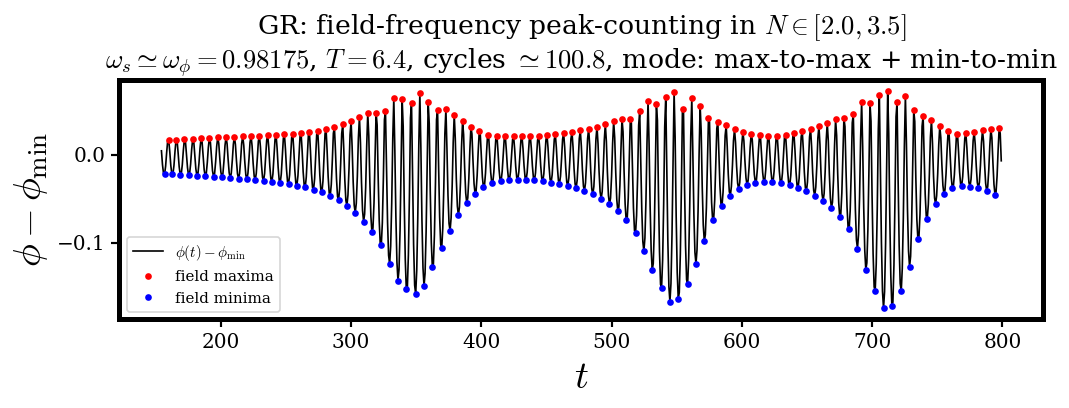

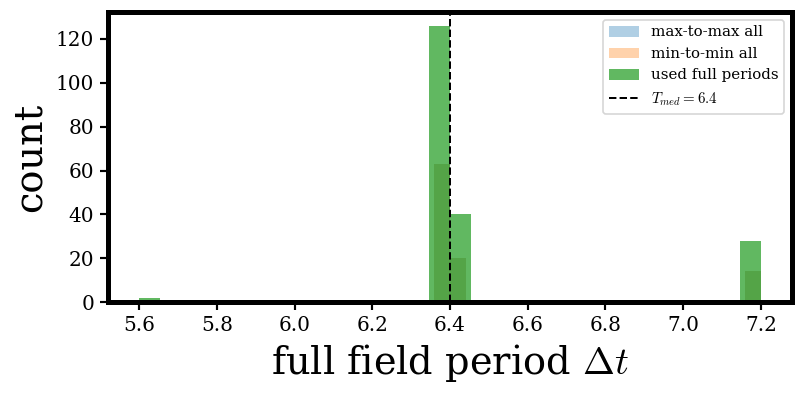

A=0.1749, R_diag=12.4, R_env=2.4489, omega_s=0.98175, omega_s*R_env=2.4042, a_f=4.372, Delta_N=1.4752, Delta_t=644.8, cycles≈100.750


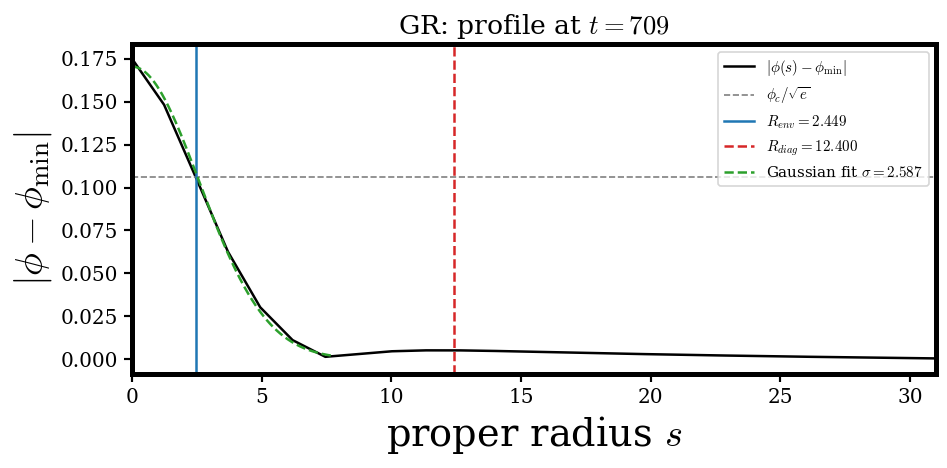

Computing GW spectrum...
done: peak k_phys(N_f)/omega_s = 0.8539, Omega_max = 7.7457e-11

Computed 1 spectrum/spectra; skipped 0.
  saved GW_spectrum_actual_background_field_frequency.pdf and GW_spectrum_actual_background_field_frequency.png


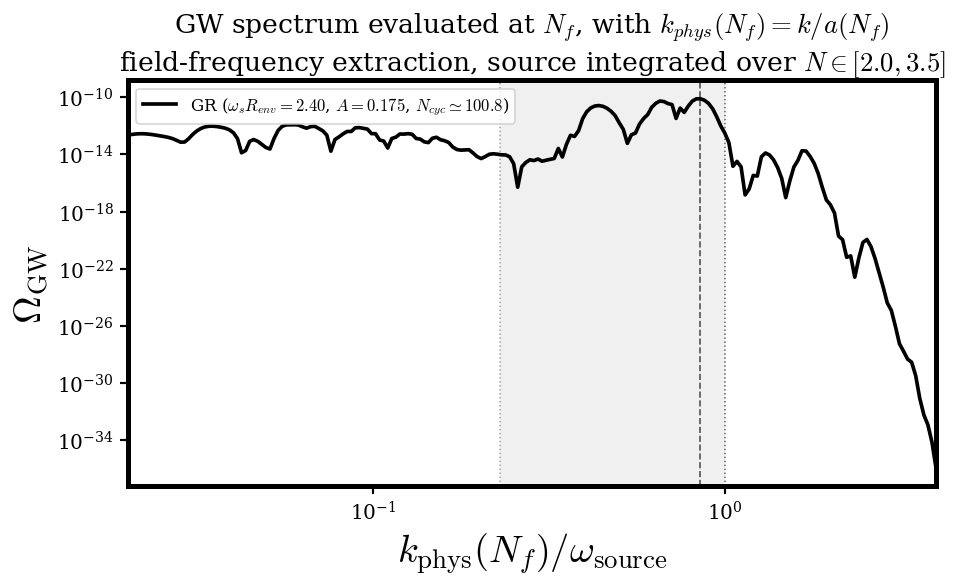


Summary:
label                       A      R_env    omega_s    omega R    Delta t     cycles        a_f   peak/omega    Omega_max
----------------------------------------------------------------------------------------------------------------------------------
GR                 1.7490e-01 2.4489e+00 9.8175e-01 2.4042e+00 6.4480e+02   100.7500 4.3720e+00   8.5390e-01   7.7457e-11


In [23]:
# ============================================================================
# Corrected GW spectra pipeline
#
#   - Select simulations as before with select_runs(...)
#   - Compare over fixed N = ln(a) window
#   - Extract omega_source from FIELD phi(t), not phi^2(t)
#   - For asymmetric potentials: omega_source ≈ omega_field
#   - Use actual simulation a(t), H(t), tau(t)
#   - Use measured Phi^2(t) as the time-dependent GW source, but subtract DC
#   - No Fourier decomposition
#   - Plot spectrum versus k_phys(N_f) / omega_source
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.signal import find_peaks
from scipy.optimize import curve_fit

try:
    from scipy.integrate import cumulative_trapezoid
except ImportError:
    from scipy.integrate import cumtrapz as cumulative_trapezoid

try:
    from scipy.signal.windows import tukey
except Exception:
    tukey = None

from bssn import GWSignal as gws
from bssn.GWSignal import OscillonRun, DEFAULT_DELTA, PHI_MIN
from core.spacing import NUM_GHOSTS
from bssn.bssnstatevariables import NUM_BSSN_VARS

if hasattr(np, "trapezoid"):
    _trapz = np.trapezoid
else:
    _trapz = np.trapz


# =============================================================================
# 0. USER SETTINGS
# =============================================================================

PLOT_KEYS = select_runs(
    lgb=[0],
    mu=[0.08],
    beta=[0],
    amp=[-0.02],
    width=[3.0],
    g2=[0],
)

STABLE_WINDOW = (2.0, 3.5)

DELTA = DEFAULT_DELTA
N_OSC = 1
SEED = 42

# Numerical resolution
N_ANGLES = 20
N_TAU_GW = 2500
N_K = 200

# k_phys(N_f) range
K_MIN_FAC_OMEGA = 0.02
K_MAX_FAC_OMEGA = 4.0
K_MAX_FAC_RADIUS = 3.0

# Field-frequency peak-counting controls
FIELD_PEAK_PROMINENCE_RATIO = 0.02
FIELD_MIN_SEPARATION_TIME = 2.0
FIELD_SMOOTH_SAMPLES = 1

# How to extract the field period:
#   "maxmin_full_period" = use max-to-max and min-to-min spacings, then combine
#   "maxima"             = use max-to-max only
#   "minima"             = use min-to-min only
FIELD_PERIOD_MODE = "maxmin_full_period"

# Source treatment in GW integral
SOURCE_SUBTRACT_MEAN = True
SOURCE_TAPER_ALPHA = 0.05

# Proper-radius extraction
PHI_BSSN_IDX = 0
PROPER_FACTOR_EXP = 2.0

SHOW_FIELD_PEAKS = True
SHOW_PROFILE = True

# Plotting
P_LOG_X = True
P_SHOW_PEAKS = True
P_SHOW_SOURCE_REDSHIFT_BAND = True
P_NAME = "GW_spectrum_actual_background_field_frequency"


# =============================================================================
# 1. Helpers
# =============================================================================

def _label(key):
    lgb, mu, beta, amp, width, g2 = key
    if lgb == 0.0 and g2 == 0.0:
        return "GR"
    if lgb != 0.0 and g2 != 0.0:
        return rf"$\lambda_{{GB}}={lgb:g},\ g_2={g2:g}$"
    if lgb != 0.0:
        return rf"$\lambda_{{GB}}={lgb:g}$"
    return rf"$g_2={g2:g}$"


def _color(idx, key):
    lgb, mu, beta, amp, width, g2 = key
    return "k" if (lgb == 0.0 and g2 == 0.0) else cm.tab10(idx % 10)


def _gauss(s, A, sigma):
    return A * np.exp(-s**2 / (2.0 * sigma**2))


def _moving_average(y, window):
    y = np.asarray(y, dtype=float)
    window = int(window)
    if window <= 1:
        return y.copy()
    window = max(3, window if window % 2 == 1 else window + 1)
    if window >= y.size:
        return y.copy()
    kernel = np.ones(window) / window
    return np.convolve(y, kernel, mode="same")


def _sort_unique_by_N(t, N, H, phi):
    order = np.argsort(N, kind="mergesort")
    t, N, H, phi = t[order], N[order], H[order], phi[order]

    keep = np.concatenate([[True], np.diff(N) > 0])
    return t[keep], N[keep], H[keep], phi[keep]


def _robust_period_filter(periods):
    periods = np.asarray(periods, dtype=float)
    periods = periods[np.isfinite(periods) & (periods > 0)]

    if periods.size < 3:
        return periods, np.ones_like(periods, dtype=bool)

    q25 = np.quantile(periods, 0.25)
    q50 = np.quantile(periods, 0.50)
    q75 = np.quantile(periods, 0.75)

    small = periods[periods <= q75]
    T0 = float(np.median(small)) if small.size else float(q50)

    keep = (
        np.isfinite(periods)
        & (periods > 0.50 * T0)
        & (periods < 1.80 * T0)
    )

    if np.sum(keep) < 3:
        iqr = max(q75 - q25, 1e-30)
        keep = (periods > q25 - 1.5 * iqr) & (periods < q75 + 1.5 * iqr)

    return periods[keep], keep


def _fit_power_law(k_phys, Omega, omega_source):
    k_phys = np.asarray(k_phys, dtype=float)
    Omega = np.asarray(Omega, dtype=float)

    valid = np.isfinite(k_phys) & np.isfinite(Omega) & (k_phys > 0) & (Omega > 0)

    if np.sum(valid) < 5:
        return np.nan, np.nan, np.nan

    i_peak = int(np.nanargmax(Omega))
    peak_k = float(k_phys[i_peak])

    fit_mask = valid & (k_phys < peak_k)

    if np.sum(fit_mask) < 3:
        return np.nan, np.nan, peak_k

    x = np.log(k_phys[fit_mask] / max(omega_source, 1e-30))
    y = np.log(Omega[fit_mask])

    n_GW, lnA = np.polyfit(x, y, 1)

    return float(np.exp(lnA)), float(n_GW), peak_k


# =============================================================================
# 2. Extract proper R_env = 1/sqrt(e) field half-width
# =============================================================================

def extract_R_env(run):
    sol = run._solution_array()
    mask = run._stable_mask()
    n_vars = sol.shape[1] // run.grid.num_points

    dev = np.abs(run.u_r0_t - PHI_MIN)
    s_idx = np.where(mask)[0]

    if s_idx.size == 0:
        raise RuntimeError(f"{run.label}: empty stable window {run.stable_window}")

    i_peak = s_idx[np.argmax(dev[s_idx])]

    sol2d = sol[i_peak].reshape(n_vars, run.grid.num_points)

    r_coord = run.r[NUM_GHOSTS:]
    phi_mat = np.abs(sol2d[NUM_BSSN_VARS, NUM_GHOSTS:] - PHI_MIN)
    phi_conf = sol2d[PHI_BSSN_IDX, NUM_GHOSTS:]

    e_fac = np.exp(PROPER_FACTOR_EXP * phi_conf)
    ds = 0.5 * (e_fac[1:] + e_fac[:-1]) * np.diff(r_coord)
    s_proper = np.concatenate([[0.0], np.cumsum(ds)])

    phi_c = float(phi_mat[0])
    thresh = phi_c / np.sqrt(np.e)

    i_cross = np.where(phi_mat < thresh)[0]

    if i_cross.size and i_cross[0] > 0:
        j = i_cross[0]
        p0, p1 = phi_mat[j - 1], phi_mat[j]
        s0, s1 = s_proper[j - 1], s_proper[j]
        frac = (thresh - p0) / (p1 - p0)
        R_env = s0 + frac * (s1 - s0)
        warn = ""
    else:
        R_env = s_proper[-1]
        warn = "profile never reached phi_c/sqrt(e); R_env = grid edge"

    core = phi_mat > 0.10 * phi_c

    try:
        popt, _ = curve_fit(
            _gauss,
            s_proper[core],
            phi_mat[core],
            p0=[phi_c, max(R_env, 1e-3)],
            maxfev=5000,
        )
        R_env_fit = abs(popt[1])
    except Exception:
        popt = None
        R_env_fit = np.nan

    return dict(
        R_env=float(R_env),
        R_env_fit=float(R_env_fit),
        phi_c=phi_c,
        thresh=float(thresh),
        r_coord=r_coord,
        s_proper=s_proper,
        profile=phi_mat,
        popt=popt,
        t_peak=float(run.t[i_peak]),
        warn=warn,
    )


# =============================================================================
# 3. Build actual simulation arrays in fixed N-window
# =============================================================================

def get_window_arrays(run, n_tau=N_TAU_GW):
    t_all = np.asarray(run.t, dtype=float)
    N_all = np.asarray(run.diag["ln_a"], dtype=float)
    H_all = -np.asarray(run.diag["K_avg"], dtype=float) / 3.0
    phi_all = np.asarray(run.u_r0_t, dtype=float)

    lo, hi = run.stable_window

    good = (
        np.isfinite(t_all)
        & np.isfinite(N_all)
        & np.isfinite(H_all)
        & np.isfinite(phi_all)
        & (H_all > 0)
        & (N_all >= lo)
        & (N_all <= hi)
    )

    if np.sum(good) < 8:
        raise RuntimeError(
            f"{run.label}: too few samples in N-window {run.stable_window}: {np.sum(good)}"
        )

    t_raw = t_all[good]
    N_raw = N_all[good]
    H_raw = H_all[good]
    phi_raw = phi_all[good]

    t_raw, N_raw, H_raw, phi_raw = _sort_unique_by_N(t_raw, N_raw, H_raw, phi_raw)

    N_grid = np.linspace(N_raw[0], N_raw[-1], int(n_tau))
    t_grid = np.interp(N_grid, N_raw, t_raw)
    H_grid = np.interp(N_grid, N_raw, H_raw)
    phi_grid = np.interp(N_grid, N_raw, phi_raw)

    # Normalize a=1 at the start of the comparison window.
    a_grid = np.exp(N_grid - N_grid[0])

    tau_grid = cumulative_trapezoid(
        1.0 / np.maximum(a_grid, 1e-30),
        t_grid,
        initial=0.0,
    )

    # This is the measured time-dependent source factor in the paper ansatz.
    source_signal = (phi_grid - PHI_MIN)**2

    return dict(
        t_raw=t_raw,
        N_raw=N_raw,
        H_raw=H_raw,
        phi_raw=phi_raw,
        t_grid=t_grid,
        N_grid=N_grid,
        H_grid=H_grid,
        a_grid=a_grid,
        tau_grid=tau_grid,
        phi_grid=phi_grid,
        source_signal=source_signal,
    )


# =============================================================================
# 4. Frequency extraction from FIELD phi(t), not phi^2(t)
# =============================================================================

def extract_omega_field_peak_count(
    run,
    *,
    period_mode=FIELD_PERIOD_MODE,
    prominence_ratio=FIELD_PEAK_PROMINENCE_RATIO,
    min_peak_separation_time=FIELD_MIN_SEPARATION_TIME,
    smooth_samples=FIELD_SMOOTH_SAMPLES,
    show=SHOW_FIELD_PEAKS,
):
    """
    Extract omega_source from the field phi(t) in cosmic time.

    For asymmetric potentials:
        omega_source ≈ omega_field

    period_mode:
        "maxmin_full_period": combine max-to-max and min-to-min spacings
        "maxima": use max-to-max spacings
        "minima": use min-to-min spacings
    """
    arr = get_window_arrays(run, n_tau=max(N_TAU_GW, 3000))

    t = arr["t_raw"]
    N = arr["N_raw"]
    phi = arr["phi_raw"] - PHI_MIN

    sig = _moving_average(phi, smooth_samples)

    dt_med = float(np.median(np.diff(t)))
    distance_samples = max(1, int(min_peak_separation_time / max(dt_med, 1e-30)))

    amp = float(np.nanmax(sig) - np.nanmin(sig))
    prominence = float(prominence_ratio * amp)

    max_idx, _ = find_peaks(
        sig,
        prominence=prominence,
        distance=distance_samples,
    )

    min_idx, _ = find_peaks(
        -sig,
        prominence=prominence,
        distance=distance_samples,
    )

    # Retry with weaker conditions if necessary.
    if max_idx.size < 3:
        max_idx, _ = find_peaks(
            sig,
            prominence=0.25 * prominence,
            distance=max(1, distance_samples // 2),
        )

    if min_idx.size < 3:
        min_idx, _ = find_peaks(
            -sig,
            prominence=0.25 * prominence,
            distance=max(1, distance_samples // 2),
        )

    t_max = t[max_idx]
    t_min = t[min_idx]

    periods_max_all = np.diff(t_max)
    periods_min_all = np.diff(t_min)

    periods_max, keep_max = _robust_period_filter(periods_max_all)
    periods_min, keep_min = _robust_period_filter(periods_min_all)

    if period_mode == "maxima":
        periods = periods_max
        used_mode = "maxima"
    elif period_mode == "minima":
        periods = periods_min
        used_mode = "minima"
    elif period_mode == "maxmin_full_period":
        pieces = []
        if periods_max.size:
            pieces.append(periods_max)
        if periods_min.size:
            pieces.append(periods_min)

        if not pieces:
            periods = np.array([])
        else:
            periods = np.concatenate(pieces)

        used_mode = "max-to-max + min-to-min"
    else:
        raise ValueError(
            "FIELD_PERIOD_MODE must be 'maxmin_full_period', 'maxima', or 'minima'."
        )

    periods = periods[np.isfinite(periods) & (periods > 0)]

    if periods.size < 3:
        raise RuntimeError(
            f"{run.label}: not enough field periods from peak counting. "
            "Try lowering FIELD_PEAK_PROMINENCE_RATIO or FIELD_MIN_SEPARATION_TIME."
        )

    T_med = float(np.median(periods))
    T_mean = float(np.mean(periods))
    T_std = float(np.std(periods))

    omega_field = 2.0 * np.pi / T_med
    omega_source = omega_field

    n_cycles_window = float((t[-1] - t[0]) / T_med)

    if show:
        fig, ax = plt.subplots(figsize=(9, 3.5))
        ax.plot(t, phi, "k-", lw=1.0, label=r"$\phi(t)-\phi_{\min}$")

        if max_idx.size:
            ax.plot(t[max_idx], phi[max_idx], "ro", ms=3.0, label="field maxima")

        if min_idx.size:
            ax.plot(t[min_idx], phi[min_idx], "bo", ms=3.0, label="field minima")

        ax.set_xlabel(r"$t$")
        ax.set_ylabel(r"$\phi-\phi_{\min}$")
        ax.set_title(
            rf"{run.label}: field-frequency peak-counting in $N\in[{run.stable_window[0]}, {run.stable_window[1]}]$"
            + "\n"
            + rf"$\omega_s\simeq\omega_\phi={omega_source:.5g}$, "
              rf"$T={T_med:.4g}$, "
              rf"cycles $\simeq {n_cycles_window:.1f}$, "
              rf"mode: {used_mode}"
        )
        ax.legend(fontsize=9)
        fig.tight_layout()
        plt.show()

        fig, ax = plt.subplots(figsize=(6.8, 3.4))

        if periods_max_all.size:
            ax.hist(periods_max_all, bins=40, alpha=0.35, label="max-to-max all")
        if periods_min_all.size:
            ax.hist(periods_min_all, bins=40, alpha=0.35, label="min-to-min all")

        ax.hist(periods, bins=30, alpha=0.75, label="used full periods")
        ax.axvline(T_med, color="k", ls="--", lw=1.2, label=rf"$T_{{med}}={T_med:.3g}$")
        ax.set_xlabel(r"full field period $\Delta t$")
        ax.set_ylabel("count")
        ax.legend(fontsize=9)
        fig.tight_layout()
        plt.show()

    return dict(
        omega_source=float(omega_source),
        omega_field=float(omega_field),
        f_source=float(1.0 / T_med),
        T_med=T_med,
        T_mean=T_mean,
        T_std=T_std,
        n_cycles=n_cycles_window,
        period_mode=used_mode,
        n_maxima=int(max_idx.size),
        n_minima=int(min_idx.size),
        max_idx=max_idx,
        min_idx=min_idx,
        t_max=t_max,
        t_min=t_min,
        periods_max_all=periods_max_all,
        periods_min_all=periods_min_all,
        periods_used=periods,
        prominence=prominence,
        distance_samples=distance_samples,
        field=phi,
        t=t,
        N=N,
    )


# =============================================================================
# 5. GW spectrum using actual simulation background
# =============================================================================

def Omega_GW_from_arrays(
    *,
    R,
    source_signal,
    t_grid,
    a_grid,
    tau_grid,
    H_grid,
    omega_source,
    Delta=DEFAULT_DELTA,
    N=1,
    V=None,
    n_angles=20,
    k_grid=None,
    n_k=200,
    seed=42,
    source_subtract_mean=SOURCE_SUBTRACT_MEAN,
    source_taper_alpha=SOURCE_TAPER_ALPHA,
):
    rng = np.random.default_rng(seed)

    R = float(R)
    omega_source = float(omega_source)

    t_grid = np.asarray(t_grid, dtype=float)
    a_grid = np.asarray(a_grid, dtype=float)
    tau_grid = np.asarray(tau_grid, dtype=float)
    H_grid = np.asarray(H_grid, dtype=float)
    source_signal = np.asarray(source_signal, dtype=float)

    if not (
        t_grid.size
        == a_grid.size
        == tau_grid.size
        == H_grid.size
        == source_signal.size
    ):
        raise ValueError("t_grid, a_grid, tau_grid, H_grid, source_signal must have same length.")

    if np.any(~np.isfinite(source_signal)):
        raise ValueError("source_signal contains non-finite values.")

    n_tau = t_grid.size
    a_f = float(a_grid[-1])
    H_f = float(H_grid[-1])
    rho_c = 3.0 * H_f**2

    if V is None:
        V = (100.0 * R)**3

    source_for_integral = source_signal.copy()

    # Static anisotropic stress should not be counted as radiative.
    # This also prevents artificial finite-window low-k artifacts.
    if source_subtract_mean:
        source_for_integral = source_for_integral - np.mean(source_for_integral)

    # Taper the source smoothly at the window boundaries.
    if source_taper_alpha is not None and source_taper_alpha > 0:
        if tukey is not None:
            source_for_integral *= tukey(n_tau, alpha=float(source_taper_alpha))
        else:
            source_for_integral *= np.hanning(n_tau)

    positions = gws._draw_random_positions(N, R, V, rng=rng)
    phase_shifts = np.zeros(N, dtype=int)

    source_q = np.empty((N, n_tau), dtype=float)
    source_q[0] = source_for_integral

    if N > 1:
        for q in range(1, N):
            shift = int(rng.integers(0, n_tau))
            phase_shifts[q] = shift
            source_q[q] = np.roll(source_for_integral, shift)

    # k_grid is comoving. We define the range using final-time physical k.
    if k_grid is None:
        k_phys_min = K_MIN_FAC_OMEGA * omega_source
        k_phys_max = max(
            K_MAX_FAC_OMEGA * omega_source,
            K_MAX_FAC_RADIUS * (2.0 / max(R, 1e-30)),
        )

        k_phys_min = max(k_phys_min, 1e-12)
        k_phys_max = max(k_phys_max, 10.0 * k_phys_min)

        k_phys_grid = np.logspace(
            np.log10(k_phys_min),
            np.log10(k_phys_max),
            int(n_k),
        )

        k_grid = a_f * k_phys_grid

    k_grid = np.asarray(k_grid, dtype=float)
    nk = k_grid.size

    theta = np.linspace(
        0.5 * np.pi / n_angles,
        np.pi - 0.5 * np.pi / n_angles,
        n_angles,
    )
    phi = np.linspace(0.0, 2.0 * np.pi, n_angles, endpoint=False)

    dth = np.pi / n_angles
    dph = 2.0 * np.pi / n_angles
    sin_th = np.sin(theta)

    Lambda_tab = np.empty((n_angles, n_angles, 3, 3, 3, 3))
    f_tab = np.empty((n_angles, n_angles, 3, 3))
    khat_tab = np.empty((n_angles, n_angles, 3))

    for it in range(n_angles):
        st, ct = np.sin(theta[it]), np.cos(theta[it])
        for ip in range(n_angles):
            sp, cp = np.sin(phi[ip]), np.cos(phi[ip])
            kh = np.array([st * cp, st * sp, ct])
            khat_tab[it, ip] = kh
            Lambda_tab[it, ip] = gws._Lambda_TT(kh)
            f_tab[it, ip] = gws._f_ij_polarisation(kh)

    Omega = np.zeros(nk, dtype=float)

    for ik, k in enumerate(k_grid):
        Omega_k = 0.0

        coskt = np.cos(k * tau_grid)
        sinkt = np.sin(k * tau_grid)

        for it in range(n_angles):
            for ip in range(n_angles):
                k_hat = khat_tab[it, ip]
                k_vec = (k * k_hat)[None, :]

                Lambda = Lambda_tab[it, ip]
                fij = f_tab[it, ip]

                env = gws.T_TT_single_envelope(k_vec, a_grid, R, Delta)[0]

                kdotx = positions @ (k * k_hat)
                phase_factor = np.exp(-1j * kdotx)

                multi_sum_t = (source_q.T * phase_factor[None, :]).sum(axis=1)
                T_lm = env * multi_sum_t

                Lambda_f = np.einsum("ijlm,lm->ij", Lambda, fij)

                real_part = Lambda_f[:, :, None] * T_lm.real[None, None, :]
                imag_part = Lambda_f[:, :, None] * T_lm.imag[None, None, :]

                cos_int_re = _trapz(
                    coskt[None, None, :] * a_grid[None, None, :] * real_part,
                    tau_grid,
                    axis=-1,
                )
                sin_int_re = _trapz(
                    sinkt[None, None, :] * a_grid[None, None, :] * real_part,
                    tau_grid,
                    axis=-1,
                )
                cos_int_im = _trapz(
                    coskt[None, None, :] * a_grid[None, None, :] * imag_part,
                    tau_grid,
                    axis=-1,
                )
                sin_int_im = _trapz(
                    sinkt[None, None, :] * a_grid[None, None, :] * imag_part,
                    tau_grid,
                    axis=-1,
                )

                mod_sq = (
                    cos_int_re**2
                    + sin_int_re**2
                    + cos_int_im**2
                    + sin_int_im**2
                ).sum()

                Omega_k += sin_th[it] * dth * dph * mod_sq

        Omega[ik] = (
            k**3
            / (2.0 * a_f**4 * rho_c)
            * (1.0 / V)
            * Omega_k
            / (2.0 * np.pi)**3
        )

    k_phys = k_grid / a_f
    A_GW, n_GW, peak_k_phys = _fit_power_law(k_phys, Omega, omega_source)

    return dict(
        k=k_grid,
        k_phys=k_phys,
        Omega_GW=Omega,
        peak_k=peak_k_phys,
        A_GW=A_GW,
        n_GW=n_GW,
        a_f=a_f,
        H_f=H_f,
        rho_c=rho_c,
        positions=positions,
        phase_shifts=phase_shifts,
        params=dict(
            R=R,
            Delta=Delta,
            N=N,
            V=V,
            omega_source=omega_source,
            n_angles=n_angles,
            n_tau=n_tau,
            seed=seed,
            source_subtract_mean=source_subtract_mean,
            source_taper_alpha=source_taper_alpha,
            uses_actual_background=True,
            source_frequency_from_field=True,
            uses_measured_phi_squared_source=True,
            k_phys_is_final_time=True,
        ),
    )


# =============================================================================
# 6. Load runs, extract parameters, compute spectra
# =============================================================================

runs = {}
Renv = {}
freqs = {}
arrays = {}
results = {}
skipped = []

for key in PLOT_KEYS:
    run = OscillonRun(
        all_runs[key]["run_dir"],
        label=_label(key),
        stable_window=STABLE_WINDOW,
    )

    # Avoid run.extract_all(), because that uses the old FFT omega extraction.
    run.A = run.extract_amplitude()
    run.R = run.extract_R()
    run.H0 = run.extract_H0()

    runs[key] = run

print(f"{len(runs)} run(s) loaded.")

for key, run in runs.items():
    print(f"\n--- {run.label} ---")

    try:
        Renv[key] = extract_R_env(run)

        freqs[key] = extract_omega_field_peak_count(
            run,
            period_mode=FIELD_PERIOD_MODE,
            prominence_ratio=FIELD_PEAK_PROMINENCE_RATIO,
            min_peak_separation_time=FIELD_MIN_SEPARATION_TIME,
            smooth_samples=FIELD_SMOOTH_SAMPLES,
            show=SHOW_FIELD_PEAKS,
        )

        arrays[key] = get_window_arrays(run, n_tau=N_TAU_GW)

        R_use = Renv[key]["R_env"]
        omega_s = freqs[key]["omega_source"]
        run.omega_source = omega_s

        if not all(np.isfinite(v) and v > 0 for v in [run.A, R_use, omega_s]):
            raise RuntimeError("bad extracted parameter: A, R_env, or omega_source")

        print(
            f"A={run.A:.5g}, "
            f"R_diag={run.R:.5g}, "
            f"R_env={R_use:.5g}, "
            f"omega_s={omega_s:.5g}, "
            f"omega_s*R_env={omega_s * R_use:.5g}, "
            f"a_f={arrays[key]['a_grid'][-1]:.5g}, "
            f"Delta_N={arrays[key]['N_grid'][-1] - arrays[key]['N_grid'][0]:.5g}, "
            f"Delta_t={arrays[key]['t_grid'][-1] - arrays[key]['t_grid'][0]:.5g}, "
            f"cycles≈{freqs[key]['n_cycles']:.3f}"
        )

        if Renv[key]["warn"]:
            print("R_env warning:", Renv[key]["warn"])

        if SHOW_PROFILE:
            e = Renv[key]

            fig, ax = plt.subplots(figsize=(8, 4))
            ax.plot(
                e["s_proper"],
                e["profile"],
                "k-",
                lw=1.5,
                label=r"$|\phi(s)-\phi_{\min}|$",
            )
            ax.axhline(
                e["thresh"],
                color="gray",
                ls="--",
                lw=1,
                label=r"$\phi_c/\sqrt{e}$",
            )
            ax.axvline(
                e["R_env"],
                color="C0",
                lw=1.5,
                label=rf"$R_{{env}}={e['R_env']:.3f}$",
            )
            ax.axvline(
                run.R,
                color="C3",
                ls="--",
                lw=1.5,
                label=rf"$R_{{diag}}={run.R:.3f}$",
            )

            if e["popt"] is not None and np.isfinite(e["R_env_fit"]):
                ss = np.linspace(
                    0,
                    min(3.0 * e["R_env_fit"], e["s_proper"][-1]),
                    300,
                )
                ax.plot(
                    ss,
                    _gauss(ss, *e["popt"]),
                    "C2--",
                    lw=1.5,
                    label=rf"Gaussian fit $\sigma={e['R_env_fit']:.3f}$",
                )

            ax.set_xlim(0, max(2.5 * run.R, 4.0 * e["R_env"]))
            ax.set_xlabel(r"proper radius $s$")
            ax.set_ylabel(r"$|\phi-\phi_{\min}|$")
            ax.set_title(rf"{run.label}: profile at $t={e['t_peak']:.3g}$")
            ax.legend(fontsize=9)
            fig.tight_layout()
            plt.show()

        print("Computing GW spectrum...")

        arr = arrays[key]

        res = Omega_GW_from_arrays(
            R=R_use,
            source_signal=arr["source_signal"],
            t_grid=arr["t_grid"],
            a_grid=arr["a_grid"],
            tau_grid=arr["tau_grid"],
            H_grid=arr["H_grid"],
            omega_source=omega_s,
            Delta=DELTA,
            N=N_OSC,
            V=(100.0 * run.R)**3,
            n_angles=N_ANGLES,
            n_k=N_K,
            seed=SEED,
            source_subtract_mean=SOURCE_SUBTRACT_MEAN,
            source_taper_alpha=SOURCE_TAPER_ALPHA,
        )

        results[key] = dict(
            run=run,
            res=res,
            R_env=R_use,
            omega_source=omega_s,
            freq=freqs[key],
            arrays=arr,
        )

        print(
            f"done: peak k_phys(N_f)/omega_s = {res['peak_k'] / omega_s:.4g}, "
            f"Omega_max = {np.nanmax(res['Omega_GW']):.4e}"
        )

    except Exception as exc:
        skipped.append((key, str(exc)))
        print(f"[skip] {run.label}: {exc}")

print("\n" + "=" * 90)
print(f"Computed {len(results)} spectrum/spectra; skipped {len(skipped)}.")
for key, why in skipped:
    print(f"  skipped {key}: {why}")


# =============================================================================
# 7. Plot spectra
# =============================================================================

if results:
    fig, ax = plt.subplots(figsize=(8, 5))

    for idx, (key, item) in enumerate(results.items()):
        res = item["res"]
        run = item["run"]
        omega_s = item["omega_source"]
        R_use = item["R_env"]
        c = _color(idx, key)

        # Paper definition: k_phys = k/a.
        # Here evaluated at final time N_f.
        x = res["k_phys"] / omega_s
        y = res["Omega_GW"]

        label = (
            rf"{run.label} "
            rf"($\omega_s R_{{env}}={omega_s * R_use:.2f}$, "
            rf"$A={run.A:.3f}$, "
            rf"$N_{{cyc}}\simeq {item['freq']['n_cycles']:.1f}$)"
        )

        if P_LOG_X:
            ax.loglog(x, y, color=c, lw=2.2, label=label)
        else:
            ax.semilogy(x, y, color=c, lw=2.2, label=label)

        if P_SHOW_PEAKS:
            i_pk = int(np.nanargmax(y))
            ax.axvline(x[i_pk], color=c, ls="--", lw=1.0, alpha=0.65)

        if P_SHOW_SOURCE_REDSHIFT_BAND:
            a_f = res["a_f"]

            # If source emits at frequency omega_s at N_emit, then at N_f:
            #
            #     k_phys(N_f) / omega_s = a(N_emit) / a(N_f).
            #
            # Since a(start)=1 and a(end)=a_f, the fundamental band is [1/a_f, 1].
            ax.axvspan(1.0 / a_f, 1.0, color=c, alpha=0.06, lw=0)
            ax.axvline(1.0, color=c, ls=":", lw=0.9, alpha=0.6)
            ax.axvline(1.0 / a_f, color=c, ls=":", lw=0.9, alpha=0.35)

    ax.set_xlabel(r"$k_{\rm phys}(N_f)/\omega_{\rm source}$")
    ax.set_ylabel(r"$\Omega_{\rm GW}$")
    ax.set_title(
        rf"GW spectrum evaluated at $N_f$, with $k_{{phys}}(N_f)=k/a(N_f)$"
        + "\n"
        + rf"field-frequency extraction, source integrated over $N\in[{STABLE_WINDOW[0]}, {STABLE_WINDOW[1]}]$"
    )

    if P_LOG_X:
        ax.set_xlim(2e-2, 4e0)
    else:
        ax.set_xlim(-0.05, 4.0)

    ax.legend(fontsize=10)
    fig.tight_layout()

    try:
        save_fig(fig, P_NAME)
    except NameError:
        pass

    plt.show()

    # Optional ratio plot
    keys = list(results.keys())

    if len(keys) >= 2:
        ref_key = keys[0]
        ref = results[ref_key]

        x_ref = ref["res"]["k_phys"] / ref["omega_source"]
        y_ref = ref["res"]["Omega_GW"]

        fig, ax = plt.subplots(figsize=(8, 3.8))

        for idx, key in enumerate(keys[1:], start=1):
            item = results[key]

            x = item["res"]["k_phys"] / item["omega_source"]
            y = item["res"]["Omega_GW"]

            y_on_ref = np.interp(x_ref, x, y, left=np.nan, right=np.nan)
            ratio = y_on_ref / np.where(y_ref > 0, y_ref, np.nan)

            ax.semilogx(
                x_ref,
                ratio,
                lw=1.5,
                color=_color(idx, key),
                label=rf"{item['run'].label} / {ref['run'].label}",
            )

        ax.axhline(1.0, color="gray", ls=":", lw=1.0)
        ax.set_xlabel(r"$k_{\rm phys}(N_f)/\omega_{\rm source,ref}$")
        ax.set_ylabel("spectrum ratio")
        ax.legend(fontsize=9)
        fig.tight_layout()
        plt.show()

    # Summary table
    print("\nSummary:")
    print(
        f"{'label':<18s} "
        f"{'A':>10s} "
        f"{'R_env':>10s} "
        f"{'omega_s':>10s} "
        f"{'omega R':>10s} "
        f"{'Delta t':>10s} "
        f"{'cycles':>10s} "
        f"{'a_f':>10s} "
        f"{'peak/omega':>12s} "
        f"{'Omega_max':>12s}"
    )
    print("-" * 130)

    for key, item in results.items():
        run = item["run"]
        arr = item["arrays"]
        res = item["res"]
        omega_s = item["omega_source"]
        R_use = item["R_env"]

        Delta_t = arr["t_grid"][-1] - arr["t_grid"][0]
        cycles = item["freq"]["n_cycles"]

        print(
            f"{run.label:<18s} "
            f"{run.A:10.4e} "
            f"{R_use:10.4e} "
            f"{omega_s:10.4e} "
            f"{omega_s * R_use:10.4e} "
            f"{Delta_t:10.4e} "
            f"{cycles:10.4f} "
            f"{res['a_f']:10.4e} "
            f"{res['peak_k'] / omega_s:12.4e} "
            f"{np.nanmax(res['Omega_GW']):12.4e}"
        )

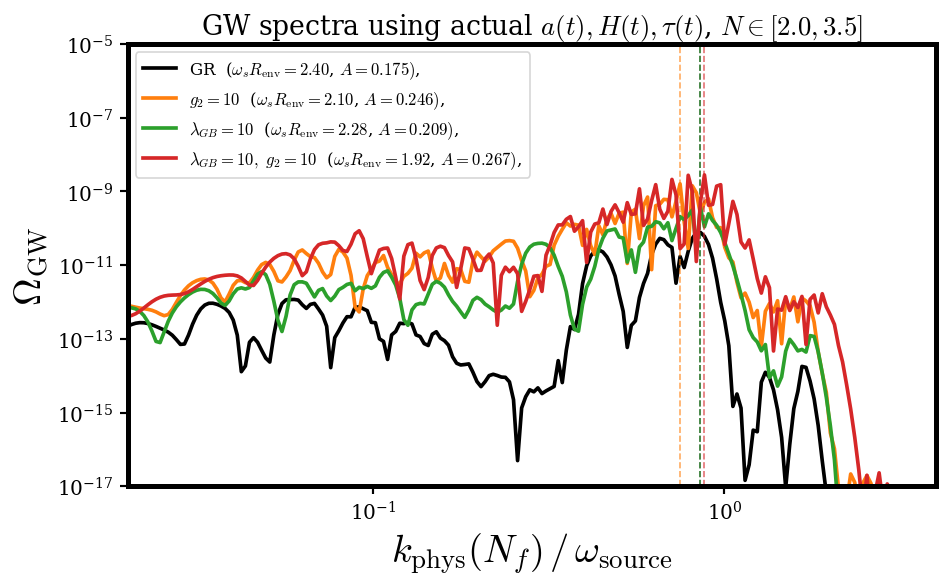

In [23]:
# ── Plot spectra from the new pipeline ───────────────────────────────────────
P_LOG_X = True
P_SHOW_PEAKS = True
P_SHOW_HARMONICS = False          # simple reference lines at n * omega_source
P_SHOW_REDSHIFT_BANDS = False     # harmonic emitted anywhere in the N-window
P_N_HARMONICS = 4
P_NAME = "GW_spectrum_actual_background_peakcount"

fig, ax = plt.subplots(figsize=(8, 5))

for idx, (key, item) in enumerate(results.items()):
    res = item["res"]
    run = item["run"]
    omega_s = item["omega_source"]
    R_env = item["R_env"]

    x = res["k_phys"] / omega_s
    y = res["Omega_GW"]
    c = _color(idx, key)

    label = (
        rf"{run.label}  "
        rf"($\omega_s R_{{\rm env}}={omega_s * R_env:.2f}$, "
        rf"$A={run.A:.3f})$, "
        #rf"$N_{{cyc}}\simeq {item['freq']['n_cycles']:.1f}$)"
    )

    if P_LOG_X:
        ax.loglog(x, y, color=c, lw=2.2, label=label)
    else:
        ax.semilogy(x, y, color=c, lw=2.2, label=label)

    # Peak of the GW spectrum
    if P_SHOW_PEAKS and np.any(np.isfinite(y)):
        i_pk = int(np.nanargmax(y))
        ax.axvline(x[i_pk], color=c, ls="--", lw=1.0, alpha=0.65)

    # Reference source harmonics.
    # Since x = k_phys(N_f) / omega_s, emission at the end gives x ≈ n.
    # Emission earlier in the window redshifts to x ≈ n / a_f.
    if P_SHOW_HARMONICS:
        a_f = res["a_f"]

        for n in range(1, P_N_HARMONICS + 1):
            x_end = float(n)
            x_start = float(n / a_f)

            if P_SHOW_REDSHIFT_BANDS:
                ax.axvspan(
                    x_start, x_end,
                    color=c,
                    alpha=0.05 if n == 1 else 0.025,
                    lw=0,
                )

            ax.axvline(
                x_end,
                color=c,
                ls=":",
                lw=0.8,
                alpha=0.65 if n == 1 else 0.35,
            )

ax.set_xlabel(r"$k_{\rm phys}(N_f)\,/\,\omega_{\rm source}$")
ax.set_ylabel(r"$\Omega_{\rm GW}$")

if P_LOG_X:
    ax.set_xlim(2e-2, 4e0)
else:
    ax.set_xlim(-0.05, 4.0)

# Adjust if needed.
ax.set_ylim(1e-17, 1e-5)

ax.set_title(
    rf"GW spectra using actual $a(t),H(t),\tau(t)$, "
    rf"$N\in[{STABLE_WINDOW[0]}, {STABLE_WINDOW[1]}]$"
)

ax.legend(fontsize=10)
fig.tight_layout()
"""
try:
    save_fig(fig, P_NAME)
except NameError:
    pass
"""
plt.show()

In [ ]:
# ============================================================================
# GW spectra pipeline on a FIXED FLRW background
#
#   - Select simulations as before with select_runs(...)
#   - Compare over fixed N = ln(a) window
#   - Extract omega_source from FIELD phi(t_FLRW), not phi^2(t)
#   - For asymmetric potentials: omega_source ≈ omega_field
#   - Use fixed FLRW a(t), H(t), tau(t), not the simulation background
#   - Use measured Phi^2(N) as the time-dependent GW source
#   - No Fourier decomposition
#   - Plot spectrum versus k_phys(N_f) / omega_source
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.signal import find_peaks
from scipy.optimize import curve_fit

try:
    from scipy.integrate import cumulative_trapezoid
except ImportError:
    from scipy.integrate import cumtrapz as cumulative_trapezoid

try:
    from scipy.signal.windows import tukey
except Exception:
    tukey = None

from bssn import GWSignal as gws
from bssn.GWSignal import OscillonRun, DEFAULT_DELTA, PHI_MIN
from core.spacing import NUM_GHOSTS
from bssn.bssnstatevariables import NUM_BSSN_VARS

if hasattr(np, "trapezoid"):
    _trapz = np.trapezoid
else:
    _trapz = np.trapz


# =============================================================================
# 0. USER SETTINGS
# =============================================================================

PLOT_KEYS = select_runs(
    lgb=[0],
    mu=[0.08],
    beta=[0],
    amp=[-0.02],
    width=[3.0],
    g2=[0, 10],
)

STABLE_WINDOW = (2.0, 3.5)

# Fixed FLRW background settings
FLRW_W = 0.0

# Options:
#   "common_first_run" : use H0 from first selected run for all runs
#   "per_run"          : use each run's own extracted H0, but still FLRW with fixed w
#   "manual"           : use FLRW_H0_MANUAL for all runs
FLRW_H0_MODE = "common_first_run"
FLRW_H0_MANUAL = None  # e.g. 1.0e-3 if FLRW_H0_MODE == "manual"

DELTA = DEFAULT_DELTA
N_OSC = 1
SEED = 42

# Numerical resolution
N_ANGLES = 20
N_TAU_GW = 2500
N_K = 200

# k_phys(N_f) range
K_MIN_FAC_OMEGA = 0.02
K_MAX_FAC_OMEGA = 4.0
K_MAX_FAC_RADIUS = 3.0

# Field-frequency peak-counting controls
FIELD_PEAK_PROMINENCE_RATIO = 0.02
FIELD_MIN_SEPARATION_TIME = 2.0
FIELD_SMOOTH_SAMPLES = 1

# How to extract the field period:
#   "maxmin_full_period" = use max-to-max and min-to-min spacings, then combine
#   "maxima"             = use max-to-max only
#   "minima"             = use min-to-min only
FIELD_PERIOD_MODE = "maxmin_full_period"

# Source treatment in GW integral
SOURCE_SUBTRACT_MEAN = True
SOURCE_TAPER_ALPHA = 0.05

# Proper-radius extraction
PHI_BSSN_IDX = 0
PROPER_FACTOR_EXP = 2.0

SHOW_FIELD_PEAKS = True
SHOW_PROFILE = True

# Plotting
P_LOG_X = True
P_SHOW_PEAKS = True
P_SHOW_SOURCE_REDSHIFT_BAND = True
P_NAME = "GW_spectrum_fixed_FLRW_field_frequency"


# =============================================================================
# 1. Helpers
# =============================================================================

def _label(key):
    lgb, mu, beta, amp, width, g2 = key
    if lgb == 0.0 and g2 == 0.0:
        return "GR"
    if lgb != 0.0 and g2 != 0.0:
        return rf"$\lambda_{{GB}}={lgb:g},\ g_2={g2:g}$"
    if lgb != 0.0:
        return rf"$\lambda_{{GB}}={lgb:g}$"
    return rf"$g_2={g2:g}$"


def _color(idx, key):
    lgb, mu, beta, amp, width, g2 = key
    return "k" if (lgb == 0.0 and g2 == 0.0) else cm.tab10(idx % 10)


def _gauss(s, A, sigma):
    return A * np.exp(-s**2 / (2.0 * sigma**2))


def _moving_average(y, window):
    y = np.asarray(y, dtype=float)
    window = int(window)
    if window <= 1:
        return y.copy()
    window = max(3, window if window % 2 == 1 else window + 1)
    if window >= y.size:
        return y.copy()
    kernel = np.ones(window) / window
    return np.convolve(y, kernel, mode="same")


def _sort_unique_by_N(t, N, H, phi):
    order = np.argsort(N, kind="mergesort")
    t, N, H, phi = t[order], N[order], H[order], phi[order]

    keep = np.concatenate([[True], np.diff(N) > 0])
    return t[keep], N[keep], H[keep], phi[keep]


def _robust_period_filter(periods):
    periods = np.asarray(periods, dtype=float)
    periods = periods[np.isfinite(periods) & (periods > 0)]

    if periods.size < 3:
        return periods, np.ones_like(periods, dtype=bool)

    q25 = np.quantile(periods, 0.25)
    q50 = np.quantile(periods, 0.50)
    q75 = np.quantile(periods, 0.75)

    small = periods[periods <= q75]
    T0 = float(np.median(small)) if small.size else float(q50)

    keep = (
        np.isfinite(periods)
        & (periods > 0.50 * T0)
        & (periods < 1.80 * T0)
    )

    if np.sum(keep) < 3:
        iqr = max(q75 - q25, 1e-30)
        keep = (periods > q25 - 1.5 * iqr) & (periods < q75 + 1.5 * iqr)

    return periods[keep], keep


def _fit_power_law(k_phys, Omega, omega_source):
    k_phys = np.asarray(k_phys, dtype=float)
    Omega = np.asarray(Omega, dtype=float)

    valid = np.isfinite(k_phys) & np.isfinite(Omega) & (k_phys > 0) & (Omega > 0)

    if np.sum(valid) < 5:
        return np.nan, np.nan, np.nan

    i_peak = int(np.nanargmax(Omega))
    peak_k = float(k_phys[i_peak])

    fit_mask = valid & (k_phys < peak_k)

    if np.sum(fit_mask) < 3:
        return np.nan, np.nan, peak_k

    x = np.log(k_phys[fit_mask] / max(omega_source, 1e-30))
    y = np.log(Omega[fit_mask])

    n_GW, lnA = np.polyfit(x, y, 1)

    return float(np.exp(lnA)), float(n_GW), peak_k


# =============================================================================
# 2. Extract proper R_env = 1/sqrt(e) field half-width
# =============================================================================

def extract_R_env(run):
    sol = run._solution_array()
    mask = run._stable_mask()
    n_vars = sol.shape[1] // run.grid.num_points

    dev = np.abs(run.u_r0_t - PHI_MIN)
    s_idx = np.where(mask)[0]

    if s_idx.size == 0:
        raise RuntimeError(f"{run.label}: empty stable window {run.stable_window}")

    i_peak = s_idx[np.argmax(dev[s_idx])]

    sol2d = sol[i_peak].reshape(n_vars, run.grid.num_points)

    r_coord = run.r[NUM_GHOSTS:]
    phi_mat = np.abs(sol2d[NUM_BSSN_VARS, NUM_GHOSTS:] - PHI_MIN)
    phi_conf = sol2d[PHI_BSSN_IDX, NUM_GHOSTS:]

    e_fac = np.exp(PROPER_FACTOR_EXP * phi_conf)
    ds = 0.5 * (e_fac[1:] + e_fac[:-1]) * np.diff(r_coord)
    s_proper = np.concatenate([[0.0], np.cumsum(ds)])

    phi_c = float(phi_mat[0])
    thresh = phi_c / np.sqrt(np.e)

    i_cross = np.where(phi_mat < thresh)[0]

    if i_cross.size and i_cross[0] > 0:
        j = i_cross[0]
        p0, p1 = phi_mat[j - 1], phi_mat[j]
        s0, s1 = s_proper[j - 1], s_proper[j]
        frac = (thresh - p0) / (p1 - p0)
        R_env = s0 + frac * (s1 - s0)
        warn = ""
    else:
        R_env = s_proper[-1]
        warn = "profile never reached phi_c/sqrt(e); R_env = grid edge"

    core = phi_mat > 0.10 * phi_c

    try:
        popt, _ = curve_fit(
            _gauss,
            s_proper[core],
            phi_mat[core],
            p0=[phi_c, max(R_env, 1e-3)],
            maxfev=5000,
        )
        R_env_fit = abs(popt[1])
    except Exception:
        popt = None
        R_env_fit = np.nan

    return dict(
        R_env=float(R_env),
        R_env_fit=float(R_env_fit),
        phi_c=phi_c,
        thresh=float(thresh),
        r_coord=r_coord,
        s_proper=s_proper,
        profile=phi_mat,
        popt=popt,
        t_peak=float(run.t[i_peak]),
        warn=warn,
    )


# =============================================================================
# 3. Raw simulation data as functions of N
# =============================================================================

def get_raw_window_by_N(run):
    t_all = np.asarray(run.t, dtype=float)
    N_all = np.asarray(run.diag["ln_a"], dtype=float)
    H_all = -np.asarray(run.diag["K_avg"], dtype=float) / 3.0
    phi_all = np.asarray(run.u_r0_t, dtype=float)

    lo, hi = run.stable_window

    good = (
        np.isfinite(t_all)
        & np.isfinite(N_all)
        & np.isfinite(H_all)
        & np.isfinite(phi_all)
        & (H_all > 0)
        & (N_all >= lo)
        & (N_all <= hi)
    )

    if np.sum(good) < 8:
        raise RuntimeError(
            f"{run.label}: too few samples in N-window {run.stable_window}: {np.sum(good)}"
        )

    t_raw = t_all[good]
    N_raw = N_all[good]
    H_raw = H_all[good]
    phi_raw = phi_all[good]

    t_raw, N_raw, H_raw, phi_raw = _sort_unique_by_N(t_raw, N_raw, H_raw, phi_raw)

    return dict(
        t_raw=t_raw,
        N_raw=N_raw,
        H_raw=H_raw,
        phi_raw=phi_raw,
    )


# =============================================================================
# 4. Fixed FLRW background on the same N-window
# =============================================================================

def build_fixed_flrw_window_arrays(run, H0_flrw, w_flrw=FLRW_W, n_tau=N_TAU_GW):
    """
    Uses phi(N) from the simulation, but maps it onto a fixed FLRW background.

    a(N) = exp(N - N_i)
    H(N) = H0_flrw * a(N)^[-3(1+w)/2]
    dt/dN = 1/H(N)
    dτ/dN = 1/[a(N)H(N)]
    """
    raw = get_raw_window_by_N(run)

    N_raw = raw["N_raw"]
    phi_raw = raw["phi_raw"]

    N_grid = np.linspace(N_raw[0], N_raw[-1], int(n_tau))
    phi_grid = np.interp(N_grid, N_raw, phi_raw)

    a_grid = np.exp(N_grid - N_grid[0])

    if abs(1.0 + w_flrw) < 1.0e-12:
        H_grid = np.full_like(N_grid, float(H0_flrw))
    else:
        p = 1.5 * (1.0 + float(w_flrw))
        H_grid = float(H0_flrw) * a_grid ** (-p)

    t_grid = cumulative_trapezoid(
        1.0 / np.maximum(H_grid, 1e-30),
        N_grid,
        initial=0.0,
    )

    tau_grid = cumulative_trapezoid(
        1.0 / np.maximum(a_grid * H_grid, 1e-30),
        N_grid,
        initial=0.0,
    )

    source_signal = (phi_grid - PHI_MIN)**2

    return dict(
        N_grid=N_grid,
        t_grid=t_grid,
        a_grid=a_grid,
        H_grid=H_grid,
        tau_grid=tau_grid,
        phi_grid=phi_grid,
        source_signal=source_signal,
        H0_flrw=float(H0_flrw),
        w_flrw=float(w_flrw),
        raw=raw,
    )


# =============================================================================
# 5. Frequency extraction from FIELD phi(t_FLRW)
# =============================================================================

def extract_omega_field_peak_count_from_arrays(
    label,
    arr,
    *,
    period_mode=FIELD_PERIOD_MODE,
    prominence_ratio=FIELD_PEAK_PROMINENCE_RATIO,
    min_peak_separation_time=FIELD_MIN_SEPARATION_TIME,
    smooth_samples=FIELD_SMOOTH_SAMPLES,
    show=SHOW_FIELD_PEAKS,
):
    """
    Extract omega_source from phi(t_FLRW).

    This is consistent with the fixed-FLRW source integral, because the frequency
    is measured using the same t_grid used in the GW integral.
    """
    t = np.asarray(arr["t_grid"], dtype=float)
    N = np.asarray(arr["N_grid"], dtype=float)
    phi = np.asarray(arr["phi_grid"], dtype=float) - PHI_MIN

    sig = _moving_average(phi, smooth_samples)

    dt_med = float(np.median(np.diff(t)))
    distance_samples = max(1, int(min_peak_separation_time / max(dt_med, 1e-30)))

    amp = float(np.nanmax(sig) - np.nanmin(sig))
    prominence = float(prominence_ratio * amp)

    max_idx, _ = find_peaks(
        sig,
        prominence=prominence,
        distance=distance_samples,
    )

    min_idx, _ = find_peaks(
        -sig,
        prominence=prominence,
        distance=distance_samples,
    )

    if max_idx.size < 3:
        max_idx, _ = find_peaks(
            sig,
            prominence=0.25 * prominence,
            distance=max(1, distance_samples // 2),
        )

    if min_idx.size < 3:
        min_idx, _ = find_peaks(
            -sig,
            prominence=0.25 * prominence,
            distance=max(1, distance_samples // 2),
        )

    t_max = t[max_idx]
    t_min = t[min_idx]

    periods_max_all = np.diff(t_max)
    periods_min_all = np.diff(t_min)

    periods_max, keep_max = _robust_period_filter(periods_max_all)
    periods_min, keep_min = _robust_period_filter(periods_min_all)

    if period_mode == "maxima":
        periods = periods_max
        used_mode = "maxima"
    elif period_mode == "minima":
        periods = periods_min
        used_mode = "minima"
    elif period_mode == "maxmin_full_period":
        pieces = []
        if periods_max.size:
            pieces.append(periods_max)
        if periods_min.size:
            pieces.append(periods_min)
        periods = np.concatenate(pieces) if pieces else np.array([])
        used_mode = "max-to-max + min-to-min"
    else:
        raise ValueError(
            "FIELD_PERIOD_MODE must be 'maxmin_full_period', 'maxima', or 'minima'."
        )

    periods = periods[np.isfinite(periods) & (periods > 0)]

    if periods.size < 3:
        raise RuntimeError(
            f"{label}: not enough field periods from peak counting. "
            "Try lowering FIELD_PEAK_PROMINENCE_RATIO or FIELD_MIN_SEPARATION_TIME."
        )

    T_med = float(np.median(periods))
    T_mean = float(np.mean(periods))
    T_std = float(np.std(periods))

    omega_field = 2.0 * np.pi / T_med
    omega_source = omega_field

    n_cycles_window = float((t[-1] - t[0]) / T_med)

    if show:
        fig, ax = plt.subplots(figsize=(9, 3.5))
        ax.plot(t, phi, "k-", lw=1.0, label=r"$\phi(t_{\rm FLRW})-\phi_{\min}$")

        if max_idx.size:
            ax.plot(t[max_idx], phi[max_idx], "ro", ms=3.0, label="field maxima")

        if min_idx.size:
            ax.plot(t[min_idx], phi[min_idx], "bo", ms=3.0, label="field minima")

        ax.set_xlabel(r"$t_{\rm FLRW}$")
        ax.set_ylabel(r"$\phi-\phi_{\min}$")
        ax.set_title(
            rf"{label}: field-frequency peak-counting on fixed FLRW"
            + "\n"
            + rf"$\omega_s\simeq\omega_\phi={omega_source:.5g}$, "
              rf"$T={T_med:.4g}$, "
              rf"cycles $\simeq {n_cycles_window:.1f}$, "
              rf"mode: {used_mode}"
        )
        ax.legend(fontsize=9)
        fig.tight_layout()
        plt.show()

        fig, ax = plt.subplots(figsize=(6.8, 3.4))

        if periods_max_all.size:
            ax.hist(periods_max_all, bins=40, alpha=0.35, label="max-to-max all")
        if periods_min_all.size:
            ax.hist(periods_min_all, bins=40, alpha=0.35, label="min-to-min all")

        ax.hist(periods, bins=30, alpha=0.75, label="used full periods")
        ax.axvline(T_med, color="k", ls="--", lw=1.2, label=rf"$T_{{med}}={T_med:.3g}$")
        ax.set_xlabel(r"full field period $\Delta t_{\rm FLRW}$")
        ax.set_ylabel("count")
        ax.legend(fontsize=9)
        fig.tight_layout()
        plt.show()

    return dict(
        omega_source=float(omega_source),
        omega_field=float(omega_field),
        f_source=float(1.0 / T_med),
        T_med=T_med,
        T_mean=T_mean,
        T_std=T_std,
        n_cycles=n_cycles_window,
        period_mode=used_mode,
        n_maxima=int(max_idx.size),
        n_minima=int(min_idx.size),
        max_idx=max_idx,
        min_idx=min_idx,
        t_max=t_max,
        t_min=t_min,
        periods_max_all=periods_max_all,
        periods_min_all=periods_min_all,
        periods_used=periods,
        prominence=prominence,
        distance_samples=distance_samples,
        field=phi,
        t=t,
        N=N,
    )


# =============================================================================
# 6. GW spectrum on fixed FLRW arrays
# =============================================================================

def Omega_GW_from_arrays(
    *,
    R,
    source_signal,
    t_grid,
    a_grid,
    tau_grid,
    H_grid,
    omega_source,
    Delta=DEFAULT_DELTA,
    N=1,
    V=None,
    n_angles=20,
    k_grid=None,
    n_k=200,
    seed=42,
    source_subtract_mean=SOURCE_SUBTRACT_MEAN,
    source_taper_alpha=SOURCE_TAPER_ALPHA,
):
    rng = np.random.default_rng(seed)

    R = float(R)
    omega_source = float(omega_source)

    t_grid = np.asarray(t_grid, dtype=float)
    a_grid = np.asarray(a_grid, dtype=float)
    tau_grid = np.asarray(tau_grid, dtype=float)
    H_grid = np.asarray(H_grid, dtype=float)
    source_signal = np.asarray(source_signal, dtype=float)

    if not (
        t_grid.size
        == a_grid.size
        == tau_grid.size
        == H_grid.size
        == source_signal.size
    ):
        raise ValueError("t_grid, a_grid, tau_grid, H_grid, source_signal must have same length.")

    if np.any(~np.isfinite(source_signal)):
        raise ValueError("source_signal contains non-finite values.")

    n_tau = t_grid.size
    a_f = float(a_grid[-1])
    H_f = float(H_grid[-1])
    rho_c = 3.0 * H_f**2

    if V is None:
        V = (100.0 * R)**3

    source_for_integral = source_signal.copy()

    if source_subtract_mean:
        source_for_integral = source_for_integral - np.mean(source_for_integral)

    if source_taper_alpha is not None and source_taper_alpha > 0:
        if tukey is not None:
            source_for_integral *= tukey(n_tau, alpha=float(source_taper_alpha))
        else:
            source_for_integral *= np.hanning(n_tau)

    positions = gws._draw_random_positions(N, R, V, rng=rng)
    phase_shifts = np.zeros(N, dtype=int)

    source_q = np.empty((N, n_tau), dtype=float)
    source_q[0] = source_for_integral

    if N > 1:
        for q in range(1, N):
            shift = int(rng.integers(0, n_tau))
            phase_shifts[q] = shift
            source_q[q] = np.roll(source_for_integral, shift)

    if k_grid is None:
        k_phys_min = K_MIN_FAC_OMEGA * omega_source
        k_phys_max = max(
            K_MAX_FAC_OMEGA * omega_source,
            K_MAX_FAC_RADIUS * (2.0 / max(R, 1e-30)),
        )

        k_phys_min = max(k_phys_min, 1e-12)
        k_phys_max = max(k_phys_max, 10.0 * k_phys_min)

        k_phys_grid = np.logspace(
            np.log10(k_phys_min),
            np.log10(k_phys_max),
            int(n_k),
        )

        k_grid = a_f * k_phys_grid

    k_grid = np.asarray(k_grid, dtype=float)
    nk = k_grid.size

    theta = np.linspace(
        0.5 * np.pi / n_angles,
        np.pi - 0.5 * np.pi / n_angles,
        n_angles,
    )
    phi = np.linspace(0.0, 2.0 * np.pi, n_angles, endpoint=False)

    dth = np.pi / n_angles
    dph = 2.0 * np.pi / n_angles
    sin_th = np.sin(theta)

    Lambda_tab = np.empty((n_angles, n_angles, 3, 3, 3, 3))
    f_tab = np.empty((n_angles, n_angles, 3, 3))
    khat_tab = np.empty((n_angles, n_angles, 3))

    for it in range(n_angles):
        st, ct = np.sin(theta[it]), np.cos(theta[it])
        for ip in range(n_angles):
            sp, cp = np.sin(phi[ip]), np.cos(phi[ip])
            kh = np.array([st * cp, st * sp, ct])
            khat_tab[it, ip] = kh
            Lambda_tab[it, ip] = gws._Lambda_TT(kh)
            f_tab[it, ip] = gws._f_ij_polarisation(kh)

    Omega = np.zeros(nk, dtype=float)

    for ik, k in enumerate(k_grid):
        Omega_k = 0.0

        coskt = np.cos(k * tau_grid)
        sinkt = np.sin(k * tau_grid)

        for it in range(n_angles):
            for ip in range(n_angles):
                k_hat = khat_tab[it, ip]
                k_vec = (k * k_hat)[None, :]

                Lambda = Lambda_tab[it, ip]
                fij = f_tab[it, ip]

                env = gws.T_TT_single_envelope(k_vec, a_grid, R, Delta)[0]

                kdotx = positions @ (k * k_hat)
                phase_factor = np.exp(-1j * kdotx)

                multi_sum_t = (source_q.T * phase_factor[None, :]).sum(axis=1)
                T_lm = env * multi_sum_t

                Lambda_f = np.einsum("ijlm,lm->ij", Lambda, fij)

                real_part = Lambda_f[:, :, None] * T_lm.real[None, None, :]
                imag_part = Lambda_f[:, :, None] * T_lm.imag[None, None, :]

                cos_int_re = _trapz(
                    coskt[None, None, :] * a_grid[None, None, :] * real_part,
                    tau_grid,
                    axis=-1,
                )
                sin_int_re = _trapz(
                    sinkt[None, None, :] * a_grid[None, None, :] * real_part,
                    tau_grid,
                    axis=-1,
                )
                cos_int_im = _trapz(
                    coskt[None, None, :] * a_grid[None, None, :] * imag_part,
                    tau_grid,
                    axis=-1,
                )
                sin_int_im = _trapz(
                    sinkt[None, None, :] * a_grid[None, None, :] * imag_part,
                    tau_grid,
                    axis=-1,
                )

                mod_sq = (
                    cos_int_re**2
                    + sin_int_re**2
                    + cos_int_im**2
                    + sin_int_im**2
                ).sum()

                Omega_k += sin_th[it] * dth * dph * mod_sq

        Omega[ik] = (
            k**3
            / (2.0 * a_f**4 * rho_c)
            * (1.0 / V)
            * Omega_k
            / (2.0 * np.pi)**3
        )

    k_phys = k_grid / a_f
    A_GW, n_GW, peak_k_phys = _fit_power_law(k_phys, Omega, omega_source)

    return dict(
        k=k_grid,
        k_phys=k_phys,
        Omega_GW=Omega,
        peak_k=peak_k_phys,
        A_GW=A_GW,
        n_GW=n_GW,
        a_f=a_f,
        H_f=H_f,
        rho_c=rho_c,
        positions=positions,
        phase_shifts=phase_shifts,
        params=dict(
            R=R,
            Delta=Delta,
            N=N,
            V=V,
            omega_source=omega_source,
            n_angles=n_angles,
            n_tau=n_tau,
            seed=seed,
            source_subtract_mean=source_subtract_mean,
            source_taper_alpha=source_taper_alpha,
            fixed_FLRW=True,
            w_flrw=FLRW_W,
            source_frequency_from_field=True,
            uses_measured_phi_squared_source=True,
            k_phys_is_final_time=True,
        ),
    )


# =============================================================================
# 7. Load runs and choose fixed FLRW H0
# =============================================================================

runs = {}
Renv = {}
freqs = {}
arrays = {}
results = {}
skipped = []

for key in PLOT_KEYS:
    run = OscillonRun(
        all_runs[key]["run_dir"],
        label=_label(key),
        stable_window=STABLE_WINDOW,
    )

    run.A = run.extract_amplitude()
    run.R = run.extract_R()
    run.H0 = run.extract_H0()

    runs[key] = run

print(f"{len(runs)} run(s) loaded.")

if len(runs) == 0:
    raise RuntimeError("No runs selected.")

if FLRW_H0_MODE == "manual":
    if FLRW_H0_MANUAL is None:
        raise ValueError("Set FLRW_H0_MANUAL when FLRW_H0_MODE='manual'.")
    H0_common = float(FLRW_H0_MANUAL)
elif FLRW_H0_MODE == "common_first_run":
    first_key = list(runs.keys())[0]
    H0_common = float(runs[first_key].H0)
elif FLRW_H0_MODE == "per_run":
    H0_common = None
else:
    raise ValueError("FLRW_H0_MODE must be 'common_first_run', 'per_run', or 'manual'.")

if H0_common is not None:
    print(f"Fixed FLRW background: w={FLRW_W:.4g}, common H0={H0_common:.6e}")
else:
    print(f"Fixed FLRW background: w={FLRW_W:.4g}, using each run's own H0.")


# =============================================================================
# 8. Compute spectra
# =============================================================================

for key, run in runs.items():
    print(f"\n--- {run.label} ---")

    try:
        H0_use = float(run.H0 if FLRW_H0_MODE == "per_run" else H0_common)

        Renv[key] = extract_R_env(run)

        arrays[key] = build_fixed_flrw_window_arrays(
            run,
            H0_flrw=H0_use,
            w_flrw=FLRW_W,
            n_tau=N_TAU_GW,
        )

        freqs[key] = extract_omega_field_peak_count_from_arrays(
            run.label,
            arrays[key],
            period_mode=FIELD_PERIOD_MODE,
            prominence_ratio=FIELD_PEAK_PROMINENCE_RATIO,
            min_peak_separation_time=FIELD_MIN_SEPARATION_TIME,
            smooth_samples=FIELD_SMOOTH_SAMPLES,
            show=SHOW_FIELD_PEAKS,
        )

        R_use = Renv[key]["R_env"]
        omega_s = freqs[key]["omega_source"]
        run.omega_source = omega_s

        if not all(np.isfinite(v) and v > 0 for v in [run.A, R_use, omega_s, H0_use]):
            raise RuntimeError("bad extracted parameter: A, R_env, omega_source, or H0_use")

        print(
            f"A={run.A:.5g}, "
            f"R_diag={run.R:.5g}, "
            f"R_env={R_use:.5g}, "
            f"H0_FLRW={H0_use:.5e}, "
            f"w_FLRW={FLRW_W:.4g}, "
            f"omega_s={omega_s:.5g}, "
            f"omega_s*R_env={omega_s * R_use:.5g}, "
            f"a_f={arrays[key]['a_grid'][-1]:.5g}, "
            f"Delta_N={arrays[key]['N_grid'][-1] - arrays[key]['N_grid'][0]:.5g}, "
            f"Delta_t_FLRW={arrays[key]['t_grid'][-1] - arrays[key]['t_grid'][0]:.5g}, "
            f"cycles≈{freqs[key]['n_cycles']:.3f}"
        )

        if Renv[key]["warn"]:
            print("R_env warning:", Renv[key]["warn"])

        if SHOW_PROFILE:
            e = Renv[key]

            fig, ax = plt.subplots(figsize=(8, 4))
            ax.plot(
                e["s_proper"],
                e["profile"],
                "k-",
                lw=1.5,
                label=r"$|\phi(s)-\phi_{\min}|$",
            )
            ax.axhline(
                e["thresh"],
                color="gray",
                ls="--",
                lw=1,
                label=r"$\phi_c/\sqrt{e}$",
            )
            ax.axvline(
                e["R_env"],
                color="C0",
                lw=1.5,
                label=rf"$R_{{env}}={e['R_env']:.3f}$",
            )
            ax.axvline(
                run.R,
                color="C3",
                ls="--",
                lw=1.5,
                label=rf"$R_{{diag}}={run.R:.3f}$",
            )

            if e["popt"] is not None and np.isfinite(e["R_env_fit"]):
                ss = np.linspace(
                    0,
                    min(3.0 * e["R_env_fit"], e["s_proper"][-1]),
                    300,
                )
                ax.plot(
                    ss,
                    _gauss(ss, *e["popt"]),
                    "C2--",
                    lw=1.5,
                    label=rf"Gaussian fit $\sigma={e['R_env_fit']:.3f}$",
                )

            ax.set_xlim(0, max(2.5 * run.R, 4.0 * e["R_env"]))
            ax.set_xlabel(r"proper radius $s$")
            ax.set_ylabel(r"$|\phi-\phi_{\min}|$")
            ax.set_title(rf"{run.label}: profile at $t={e['t_peak']:.3g}$")
            ax.legend(fontsize=9)
            fig.tight_layout()
            plt.show()

        print("Computing GW spectrum on fixed FLRW background...")

        arr = arrays[key]

        res = Omega_GW_from_arrays(
            R=R_use,
            source_signal=arr["source_signal"],
            t_grid=arr["t_grid"],
            a_grid=arr["a_grid"],
            tau_grid=arr["tau_grid"],
            H_grid=arr["H_grid"],
            omega_source=omega_s,
            Delta=DELTA,
            N=N_OSC,
            V=(100.0 * run.R)**3,
            n_angles=N_ANGLES,
            n_k=N_K,
            seed=SEED,
            source_subtract_mean=SOURCE_SUBTRACT_MEAN,
            source_taper_alpha=SOURCE_TAPER_ALPHA,
        )

        results[key] = dict(
            run=run,
            res=res,
            R_env=R_use,
            omega_source=omega_s,
            freq=freqs[key],
            arrays=arr,
            H0_flrw=H0_use,
            w_flrw=FLRW_W,
        )

        print(
            f"done: peak k_phys(N_f)/omega_s = {res['peak_k'] / omega_s:.4g}, "
            f"Omega_max = {np.nanmax(res['Omega_GW']):.4e}"
        )

    except Exception as exc:
        skipped.append((key, str(exc)))
        print(f"[skip] {run.label}: {exc}")

print("\n" + "=" * 90)
print(f"Computed {len(results)} spectrum/spectra; skipped {len(skipped)}.")
for key, why in skipped:
    print(f"  skipped {key}: {why}")


# =============================================================================
# 9. Plot spectra
# =============================================================================

if results:
    fig, ax = plt.subplots(figsize=(8, 5))

    for idx, (key, item) in enumerate(results.items()):
        res = item["res"]
        run = item["run"]
        omega_s = item["omega_source"]
        R_use = item["R_env"]
        c = _color(idx, key)

        x = res["k_phys"] / omega_s
        y = res["Omega_GW"]

        label = (
            rf"{run.label} "
            rf"($\omega_s R_{{env}}={omega_s * R_use:.2f}$, "
            rf"$A={run.A:.3f}$, "
            rf"$N_{{cyc}}\simeq {item['freq']['n_cycles']:.1f}$)"
        )

        if P_LOG_X:
            ax.loglog(x, y, color=c, lw=2.2, label=label)
        else:
            ax.semilogy(x, y, color=c, lw=2.2, label=label)

        if P_SHOW_PEAKS:
            i_pk = int(np.nanargmax(y))
            ax.axvline(x[i_pk], color=c, ls="--", lw=1.0, alpha=0.65)

        if P_SHOW_SOURCE_REDSHIFT_BAND:
            a_f = res["a_f"]
            ax.axvspan(1.0 / a_f, 1.0, color=c, alpha=0.06, lw=0)
            ax.axvline(1.0, color=c, ls=":", lw=0.9, alpha=0.6)
            ax.axvline(1.0 / a_f, color=c, ls=":", lw=0.9, alpha=0.35)

    ax.set_xlabel(r"$k_{\rm phys}(N_f)/\omega_{\rm source}$")
    ax.set_ylabel(r"$\Omega_{\rm GW}$")
    ax.set_title(
        rf"GW spectrum on fixed FLRW background: $w={FLRW_W}$"
        + "\n"
        + rf"$N\in[{STABLE_WINDOW[0]}, {STABLE_WINDOW[1]}]$, "
        + rf"$k_{{phys}}(N_f)=k/a(N_f)$, H0 mode: {FLRW_H0_MODE}"
    )

    if P_LOG_X:
        ax.set_xlim(2e-2, 4e0)
    else:
        ax.set_xlim(-0.05, 4.0)

    ax.legend(fontsize=10)
    fig.tight_layout()

    try:
        save_fig(fig, P_NAME)
    except NameError:
        pass

    plt.show()

    # Optional ratio plot
    keys = list(results.keys())

    if len(keys) >= 2:
        ref_key = keys[0]
        ref = results[ref_key]

        x_ref = ref["res"]["k_phys"] / ref["omega_source"]
        y_ref = ref["res"]["Omega_GW"]

        fig, ax = plt.subplots(figsize=(8, 3.8))

        for idx, key in enumerate(keys[1:], start=1):
            item = results[key]

            x = item["res"]["k_phys"] / item["omega_source"]
            y = item["res"]["Omega_GW"]

            y_on_ref = np.interp(x_ref, x, y, left=np.nan, right=np.nan)
            ratio = y_on_ref / np.where(y_ref > 0, y_ref, np.nan)

            ax.semilogx(
                x_ref,
                ratio,
                lw=1.5,
                color=_color(idx, key),
                label=rf"{item['run'].label} / {ref['run'].label}",
            )

        ax.axhline(1.0, color="gray", ls=":", lw=1.0)
        ax.set_xlabel(r"$k_{\rm phys}(N_f)/\omega_{\rm source,ref}$")
        ax.set_ylabel("spectrum ratio")
        ax.legend(fontsize=9)
        fig.tight_layout()
        plt.show()

    # Summary table
    print("\nSummary:")
    print(
        f"{'label':<18s} "
        f"{'A':>10s} "
        f"{'R_env':>10s} "
        f"{'H0_FLRW':>10s} "
        f"{'w_FLRW':>8s} "
        f"{'omega_s':>10s} "
        f"{'omega R':>10s} "
        f"{'Delta t':>10s} "
        f"{'cycles':>10s} "
        f"{'a_f':>10s} "
        f"{'peak/omega':>12s} "
        f"{'Omega_max':>12s}"
    )
    print("-" * 150)

    for key, item in results.items():
        run = item["run"]
        arr = item["arrays"]
        res = item["res"]
        omega_s = item["omega_source"]
        R_use = item["R_env"]

        Delta_t = arr["t_grid"][-1] - arr["t_grid"][0]
        cycles = item["freq"]["n_cycles"]

        print(
            f"{run.label:<18s} "
            f"{run.A:10.4e} "
            f"{R_use:10.4e} "
            f"{item['H0_flrw']:10.4e} "
            f"{item['w_flrw']:8.3f} "
            f"{omega_s:10.4e} "
            f"{omega_s * R_use:10.4e} "
            f"{Delta_t:10.4e} "
            f"{cycles:10.4f} "
            f"{res['a_f']:10.4e} "
            f"{res['peak_k'] / omega_s:12.4e} "
            f"{np.nanmax(res['Omega_GW']):12.4e}"
        )

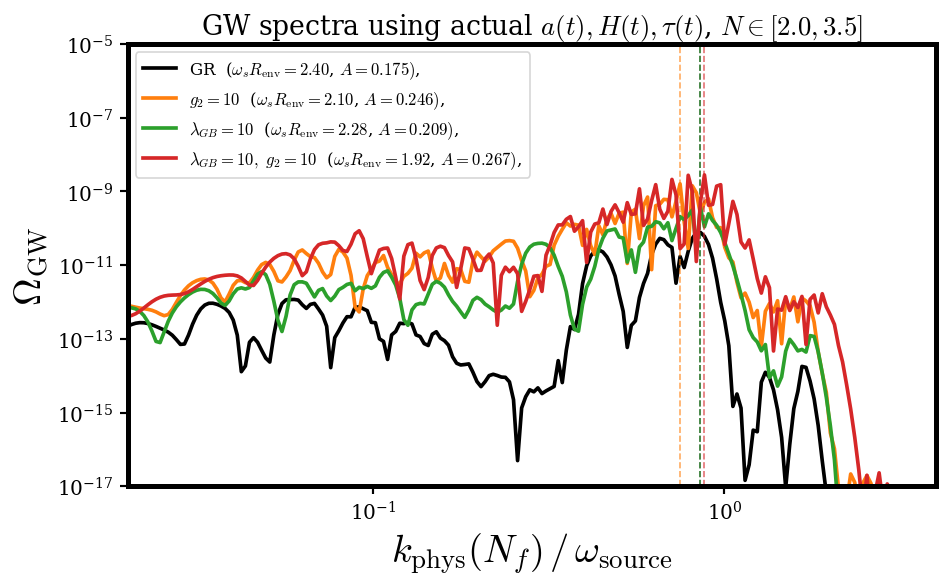

In [24]:
# ── Plot spectra from the new pipeline ───────────────────────────────────────
P_LOG_X = True
P_SHOW_PEAKS = True
P_SHOW_HARMONICS = False          # simple reference lines at n * omega_source
P_SHOW_REDSHIFT_BANDS = False     # harmonic emitted anywhere in the N-window
P_N_HARMONICS = 4
P_NAME = "GW_spectrum_actual_background_peakcount"

fig, ax = plt.subplots(figsize=(8, 5))

for idx, (key, item) in enumerate(results.items()):
    res = item["res"]
    run = item["run"]
    omega_s = item["omega_source"]
    R_env = item["R_env"]

    x = res["k_phys"] / omega_s
    y = res["Omega_GW"]
    c = _color(idx, key)

    label = (
        rf"{run.label}  "
        rf"($\omega_s R_{{\rm env}}={omega_s * R_env:.2f}$, "
        rf"$A={run.A:.3f})$, "
        #rf"$N_{{cyc}}\simeq {item['freq']['n_cycles']:.1f}$)"
    )

    if P_LOG_X:
        ax.loglog(x, y, color=c, lw=2.2, label=label)
    else:
        ax.semilogy(x, y, color=c, lw=2.2, label=label)

    # Peak of the GW spectrum
    if P_SHOW_PEAKS and np.any(np.isfinite(y)):
        i_pk = int(np.nanargmax(y))
        ax.axvline(x[i_pk], color=c, ls="--", lw=1.0, alpha=0.65)

    # Reference source harmonics.
    # Since x = k_phys(N_f) / omega_s, emission at the end gives x ≈ n.
    # Emission earlier in the window redshifts to x ≈ n / a_f.
    if P_SHOW_HARMONICS:
        a_f = res["a_f"]

        for n in range(1, P_N_HARMONICS + 1):
            x_end = float(n)
            x_start = float(n / a_f)

            if P_SHOW_REDSHIFT_BANDS:
                ax.axvspan(
                    x_start, x_end,
                    color=c,
                    alpha=0.05 if n == 1 else 0.025,
                    lw=0,
                )

            ax.axvline(
                x_end,
                color=c,
                ls=":",
                lw=0.8,
                alpha=0.65 if n == 1 else 0.35,
            )

ax.set_xlabel(r"$k_{\rm phys}(N_f)\,/\,\omega_{\rm source}$")
ax.set_ylabel(r"$\Omega_{\rm GW}$")

if P_LOG_X:
    ax.set_xlim(2e-2, 4e0)
else:
    ax.set_xlim(-0.05, 4.0)

# Adjust if needed.
ax.set_ylim(1e-17, 1e-5)

ax.set_title(
    rf"GW spectra using actual $a(t),H(t),\tau(t)$, "
    rf"$N\in[{STABLE_WINDOW[0]}, {STABLE_WINDOW[1]}]$"
)

ax.legend(fontsize=10)
fig.tight_layout()
"""
try:
    save_fig(fig, P_NAME)
except NameError:
    pass
"""
plt.show()